<a href="https://colab.research.google.com/github/yuzxin/Capstone/blob/main/%ED%9A%8C%EA%B7%80%EB%B6%84%EC%84%9D_%EC%A7%84%EC%84%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 회귀분석

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 한글 폰트 설정
!sudo apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# 데이터셋 불러오기
master_df = pd.read_csv("/content/drive/MyDrive/캡스톤/v3/master_dataset.csv", index_col=0)
robinia_df = pd.read_csv("/content/drive/MyDrive/캡스톤/v3/robinia_dataset.csv", index_col=0)
cherry_df = pd.read_csv("/content/drive/MyDrive/캡스톤/v3/cherry_dataset.csv", index_col=0)

In [ ]:
# 단순회귀분석 함수
def regression_analysis(df, x_col, y_col, title):

    # ------------------------
    # 데이터 준비
    # ------------------------
    X = df[[x_col]]
    y = df[y_col]

    # ------------------------
    # sklearn 회귀모델
    # ------------------------
    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)

    # ------------------------
    # 성능지표
    # ------------------------
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))

    print("="*70)
    print(title)
    print("="*70)

    print(f"회귀식")
    print(f"{y_col} = {model.intercept_:.3f} + ({model.coef_[0]:.3f}) × {x_col}")
    print()

    print(f"회귀계수(beta): {model.coef_[0]:.3f}")
    print(f"절편(intercept): {model.intercept_:.3f}")

    print(f"R² : {r2:.3f}")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")

    # statsmodels (p-value)
    X2 = sm.add_constant(X)

    model_sm = sm.OLS(y, X2).fit()

    print("\n[통계 검정 결과]")
    print(model_sm.summary())

    # 회귀선 + 잔차 그래프
    residuals = y - pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 회귀선
    sns.regplot(
        x=x_col,
        y=y_col,
        data=df,
        ax=axes[0],
        scatter_kws={"alpha":0.7},
        line_kws={"color":"red"}
    )

    axes[0].set_title(title)
    axes[0].grid(alpha=0.3)

    # 잔차 그래프
    axes[1].scatter(pred, residuals, alpha=0.7)
    axes[1].axhline(0,
                    color='red',
                    linestyle='--')

    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("Residual Plot")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "model": model_sm,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "coef": model.coef_[0],
        "intercept": model.intercept_,
        "pred": pred
    }

In [ ]:
# 다중회귀분석 함수
import statsmodels.api as sm

def multiple_regression(df, x_cols, y_col, title):

    sub = df[x_cols + [y_col]].dropna()

    X = sub[x_cols]
    y = sub[y_col]

    X_const = sm.add_constant(X)

    model = sm.OLS(y, X_const).fit()
    # 예측값
    pred = model.predict(X_const)

    # 잔차
    residual = y - pred

    # 평가 지표
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))

    print("="*80)
    print(title)
    print("="*80)

    print(model.summary())

    # VIF 계산
    vif = pd.DataFrame()

    vif["Variable"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

    # const 행은 제외하고 출력
    vif = vif[vif["Variable"] != 'const']

    print("\nVIF")
    print(vif)
    if (vif["VIF"]<5).all():
        print("\n다중공선성 문제 없음")
    elif (vif["VIF"]<10).all():
        print("\n주의 수준의 다중공선성")
    else:
        print("\n다중공선성이 높음")

    # 예측값 vs 실제값 + 잔차
    fig, axes = plt.subplots(1, 2, figsize=(12,5))


    # Actual vs Predicted
    axes[0].scatter(y,
                    pred,
                    alpha=0.7)

    # 기준선
    min_val=min(y.min(),pred.min())
    max_val=max(y.max(),pred.max())
    axes[0].plot(
        [min_val,max_val],
        [min_val,max_val],
        'r--'
    )
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title("Actual vs Predicted")
    axes[0].grid(alpha=0.3)

    # Residual Plot
    axes[1].scatter(pred,
                    residual,
                    alpha=0.7)
    axes[1].axhline(
        0,
        color="red",
        linestyle="--"
    )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("Residual Plot")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "coef": model.params,
        "pvalues": model.pvalues,
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
        "mae": mae,
        "rmse": rmse,
        "vif": vif
    }

# 꿀벌 활동

Spring Temperature → Bee Activity Start
회귀식
bee_start_doy = 207.756 + (-10.038) × spring_temp_avg

회귀계수(beta): -10.038
절편(intercept): 207.756
R² : 0.446
MAE : 11.203
RMSE : 14.930

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     178.5
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.87e-30
Time:                        03:09:15   Log-Likelihood:                -923.40
No. Observations:                 224   AIC:                             1851.
Df Residuals:                     222   BIC:                             1858.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  

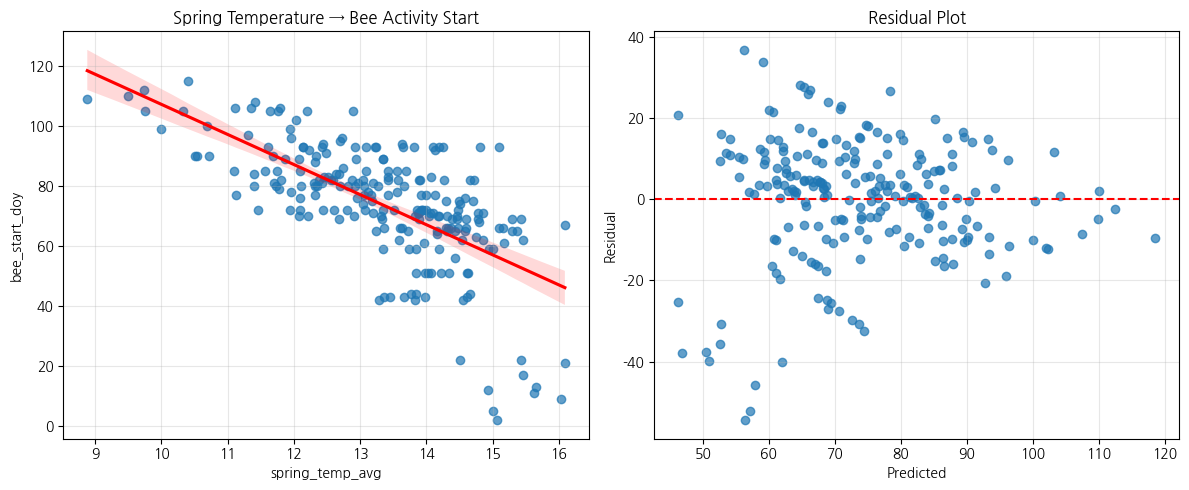

In [ ]:
## 꿀벌 활동 시작일 회귀분석
# 평균기온 → Bee DOY
bee_temp_model = regression_analysis(
    master_df,
    "spring_temp_avg",
    "bee_start_doy",
    "Spring Temperature → Bee Activity Start"
)

Accumulated Temperature → Bee Activity Start
회귀식
bee_start_doy = 159.959 + (-0.106) × accumulated_temp

회귀계수(beta): -0.106
절편(intercept): 159.959
R² : 0.567
MAE : 10.241
RMSE : 13.198

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     290.5
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.30e-42
Time:                        03:09:15   Log-Likelihood:                -895.78
No. Observations:                 224   AIC:                             1796.
Df Residuals:                     222   BIC:                             1802.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
              

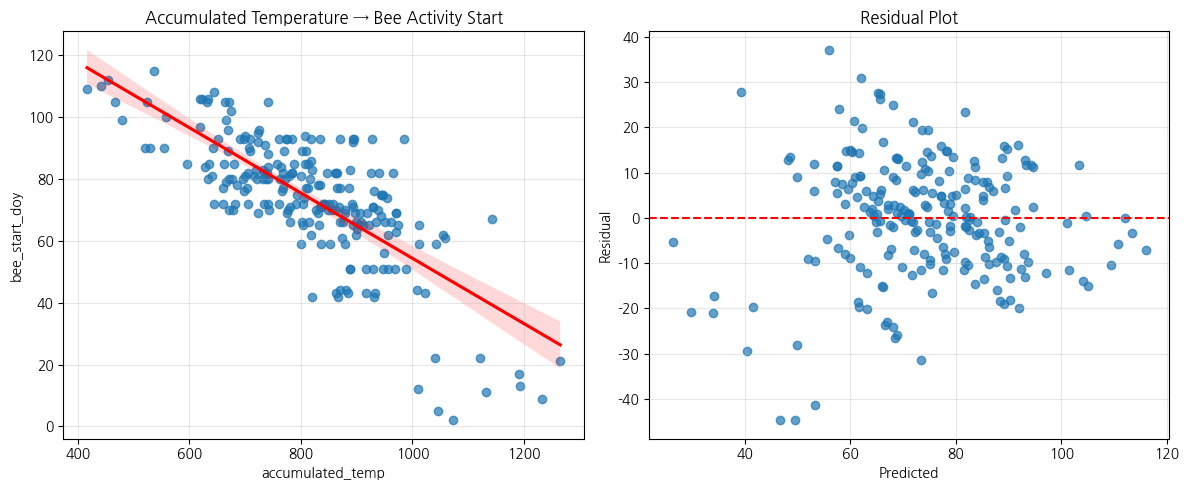

In [ ]:
# 적산온도 → Bee DOY
bee_gdd_model = regression_analysis(
    master_df,
    "accumulated_temp",
    "bee_start_doy",
    "Accumulated Temperature → Bee Activity Start"
)

Spring Rainfall → Bee Activity Start
회귀식
bee_start_doy = 90.693 + (-0.070) × spring_rainfall

회귀계수(beta): -0.070
절편(intercept): 90.693
R² : 0.158
MAE : 13.630
RMSE : 18.400

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     41.68
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           6.68e-10
Time:                        03:09:16   Log-Likelihood:                -970.21
No. Observations:                 224   AIC:                             1944.
Df Residuals:                     222   BIC:                             1951.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coe

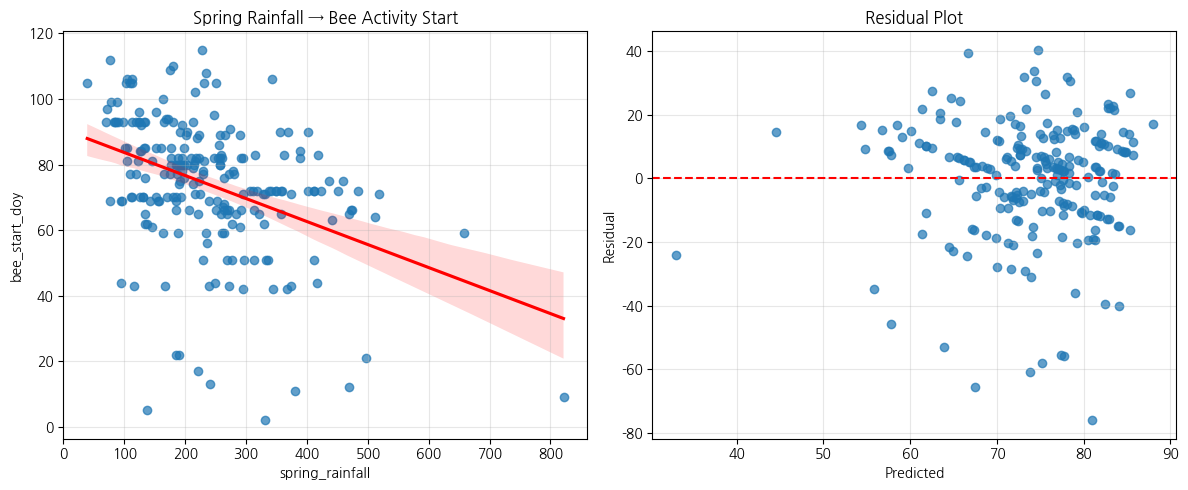

In [ ]:
# 강수량 → Bee DOY
bee_rain_model = regression_analysis(
    master_df,
    "spring_rainfall",
    "bee_start_doy",
    "Spring Rainfall → Bee Activity Start"
)

Spring Dew Point Temperature → Bee Activity Start
회귀식
bee_start_doy = 99.754 + (-4.754) × spring_dew_point_avg

회귀계수(beta): -4.754
절편(intercept): 99.754
R² : 0.212
MAE : 13.715
RMSE : 17.800

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     59.78
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.66e-13
Time:                        03:09:16   Log-Likelihood:                -962.78
No. Observations:                 224   AIC:                             1930.
Df Residuals:                     222   BIC:                             1936.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
       

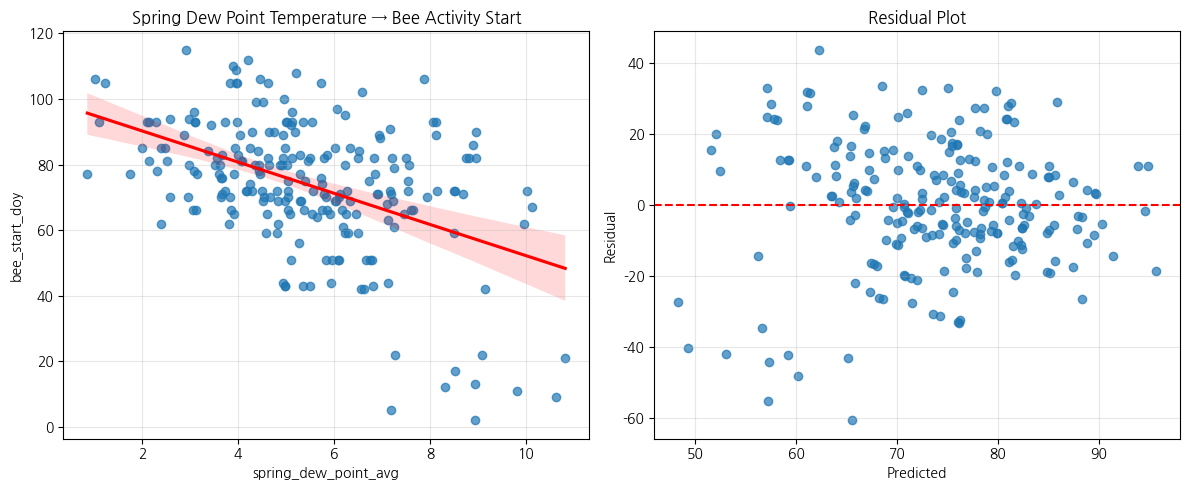

In [ ]:
# 평균 이슬점온도 → Bee DOY
bee_dew_model = regression_analysis(
    master_df,
    "spring_dew_point_avg",
    "bee_start_doy",
    "Spring Dew Point Temperature → Bee Activity Start"
)

Spring Minimum Relative Humidity → Bee Activity Start
회귀식
bee_start_doy = 88.391 + (-0.367) × spring_humidity_min

회귀계수(beta): -0.367
절편(intercept): 88.391
R² : 0.022
MAE : 14.429
RMSE : 19.832

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     4.975
Date:                Thu, 20 Aug 2026   Prob (F-statistic):             0.0267
Time:                        03:09:17   Log-Likelihood:                -987.00
No. Observations:                 224   AIC:                             1978.
Df Residuals:                     222   BIC:                             1985.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
    

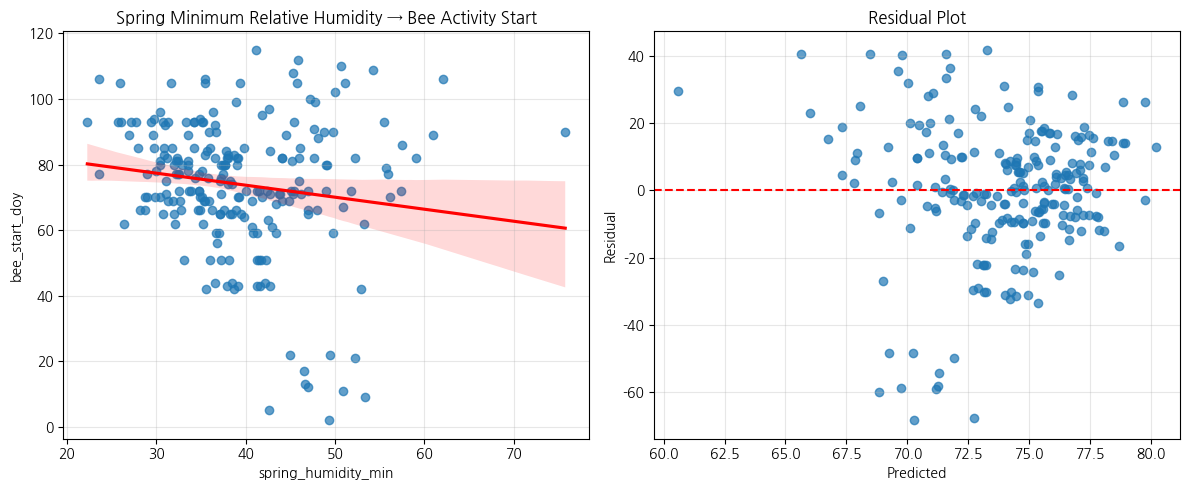

In [ ]:
# 최소 상대습도 → Bee DOY
bee_min_model = regression_analysis(
    master_df,
    "spring_humidity_min",
    "bee_start_doy",
    "Spring Minimum Relative Humidity → Bee Activity Start"
)

Spring Average Relative Humidity → Bee Activity Start
회귀식
bee_start_doy = 69.121 + (0.076) × spring_humidity_avg

회귀계수(beta): 0.076
절편(intercept): 69.121
R² : 0.001
MAE : 14.533
RMSE : 20.046

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1721
Date:                Thu, 20 Aug 2026   Prob (F-statistic):              0.679
Time:                        03:09:17   Log-Likelihood:                -989.40
No. Observations:                 224   AIC:                             1983.
Df Residuals:                     222   BIC:                             1990.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
      

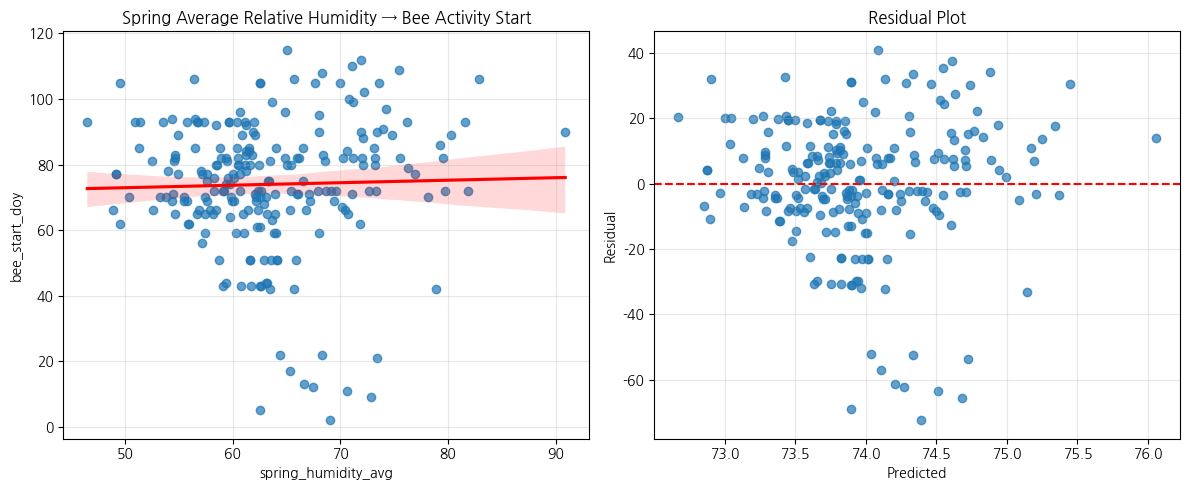

In [ ]:
# 평균 상대습도 → Bee DOY
bee_avg_model = regression_analysis(
    master_df,
    "spring_humidity_avg",
    "bee_start_doy",
    "Spring Average Relative Humidity → Bee Activity Start"
)

Spring Aaverage vapor pressure → Bee Activity Start
회귀식
bee_start_doy = 151.262 + (-7.794) × spring_vapor_pressure_avg

회귀계수(beta): -7.794
절편(intercept): 151.262
R² : 0.233
MAE : 13.576
RMSE : 17.561

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     67.49
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.75e-14
Time:                        03:09:18   Log-Likelihood:                -959.75
No. Observations:                 224   AIC:                             1924.
Df Residuals:                     222   BIC:                             1930.
Df Model:                           1                                         
Covariance Type:            nonrobust                                        

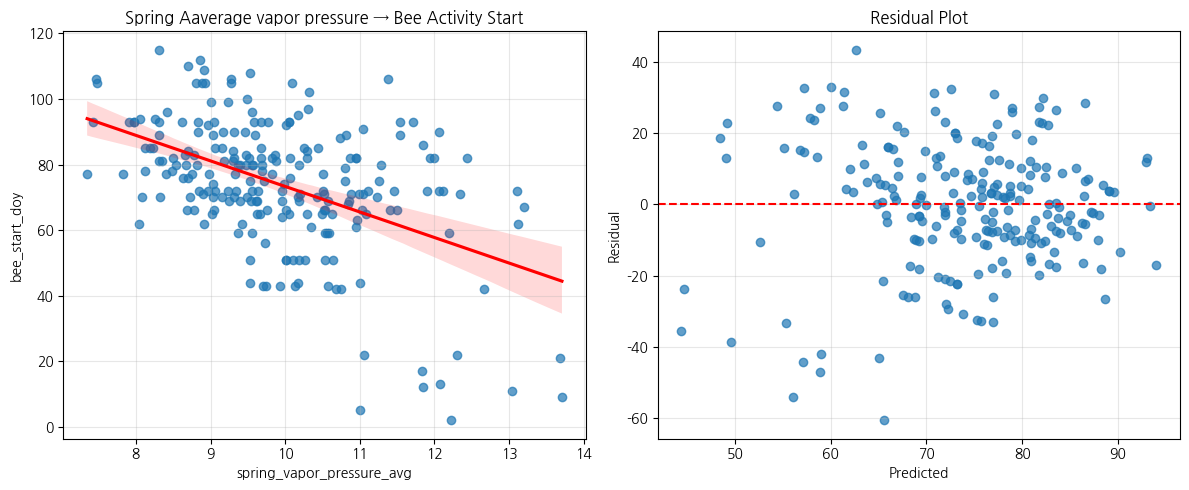

In [ ]:
# 평균 증기압 → Bee DOY
bee_vapor_model = regression_analysis(
    master_df,
    "spring_vapor_pressure_avg",
    "bee_start_doy",
    "Spring Aaverage vapor pressure → Bee Activity Start"
)

# 아까시나무

Spring Temperature → Robinia Bloom
회귀식
robinia_bloom_doy = 200.063 + (-5.696) × spring_temp_avg

회귀계수(beta): -5.696
절편(intercept): 200.063
R² : 0.767
MAE : 3.296
RMSE : 4.187

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     730.8
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.62e-72
Time:                        03:09:19   Log-Likelihood:                -638.59
No. Observations:                 224   AIC:                             1281.
Df Residuals:                     222   BIC:                             1288.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      c

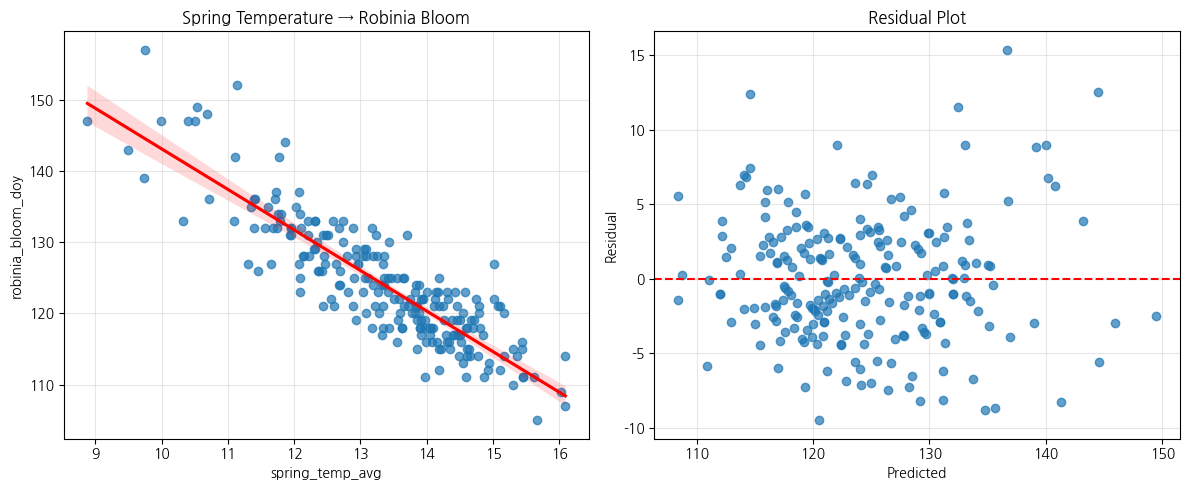

In [ ]:
## 아까시나무 회귀분석
# 평균기온 → 개화일
robinia_temp_model = regression_analysis(
    robinia_df,
    "spring_temp_avg",
    "robinia_bloom_doy",
    "Spring Temperature → Robinia Bloom"
)

Accumulated Temperature → Robinia Bloom
회귀식
robinia_bloom_doy = 165.665 + (-0.051) × accumulated_temp

회귀계수(beta): -0.051
절편(intercept): 165.665
R² : 0.706
MAE : 3.565
RMSE : 4.701

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     533.7
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           5.61e-61
Time:                        03:09:19   Log-Likelihood:                -664.55
No. Observations:                 224   AIC:                             1333.
Df Residuals:                     222   BIC:                             1340.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 

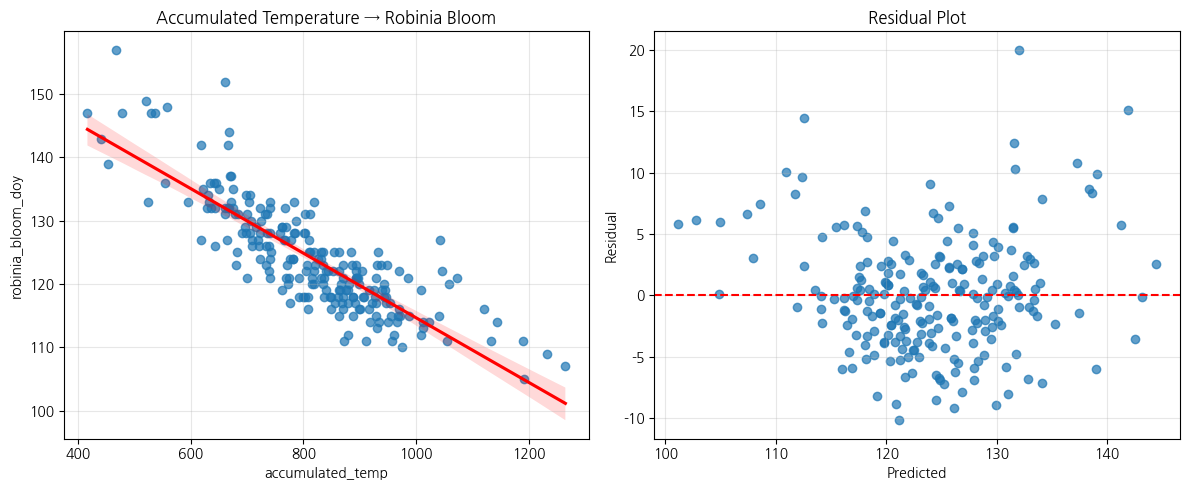

In [ ]:
# 적산온도 → 개화일
robinia_gdd_model = regression_analysis(
    robinia_df,
    "accumulated_temp",
    "robinia_bloom_doy",
    "Accumulated Temperature → Robinia Bloom"
)

Spring Rainfall → Robinia Bloom
회귀식
robinia_bloom_doy = 129.152 + (-0.021) × spring_rainfall

회귀계수(beta): -0.021
절편(intercept): 129.152
R² : 0.076
MAE : 6.448
RMSE : 8.339

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     18.16
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.00e-05
Time:                        03:09:20   Log-Likelihood:                -792.94
No. Observations:                 224   AIC:                             1590.
Df Residuals:                     222   BIC:                             1597.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef

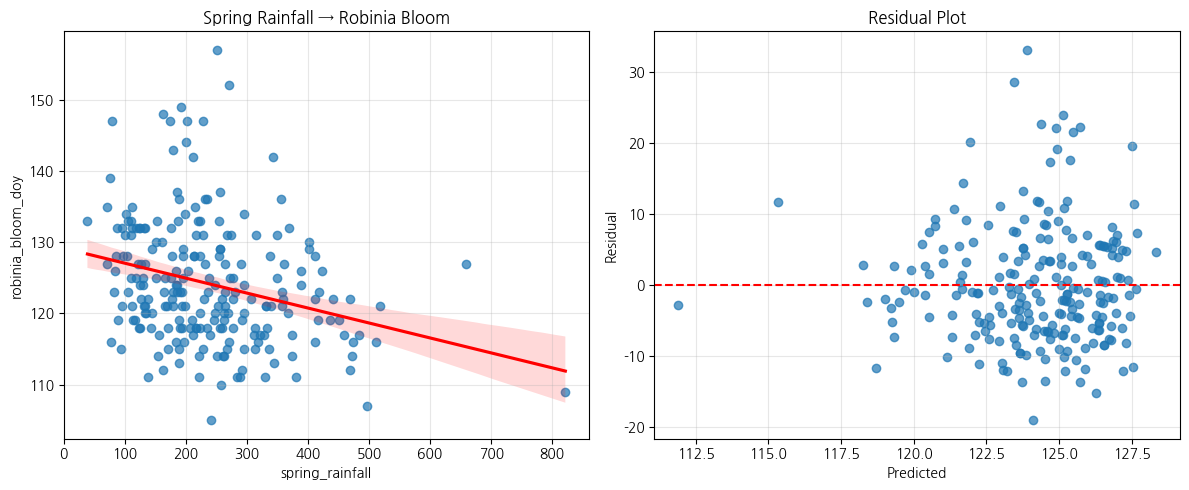

In [ ]:
# 강수량 → 개화일
robinia_rain_model = regression_analysis(
    robinia_df,
    "spring_rainfall",
    "robinia_bloom_doy",
    "Spring Rainfall → Robinia Bloom"
)

Spring Dew Point Temperature → Robinia Bloom
회귀식
robinia_bloom_doy = 130.725 + (-1.212) × spring_dew_point_avg

회귀계수(beta): -1.212
절편(intercept): 130.725
R² : 0.074
MAE : 6.261
RMSE : 8.348

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     17.68
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.79e-05
Time:                        03:09:21   Log-Likelihood:                -793.17
No. Observations:                 224   AIC:                             1590.
Df Residuals:                     222   BIC:                             1597.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
        

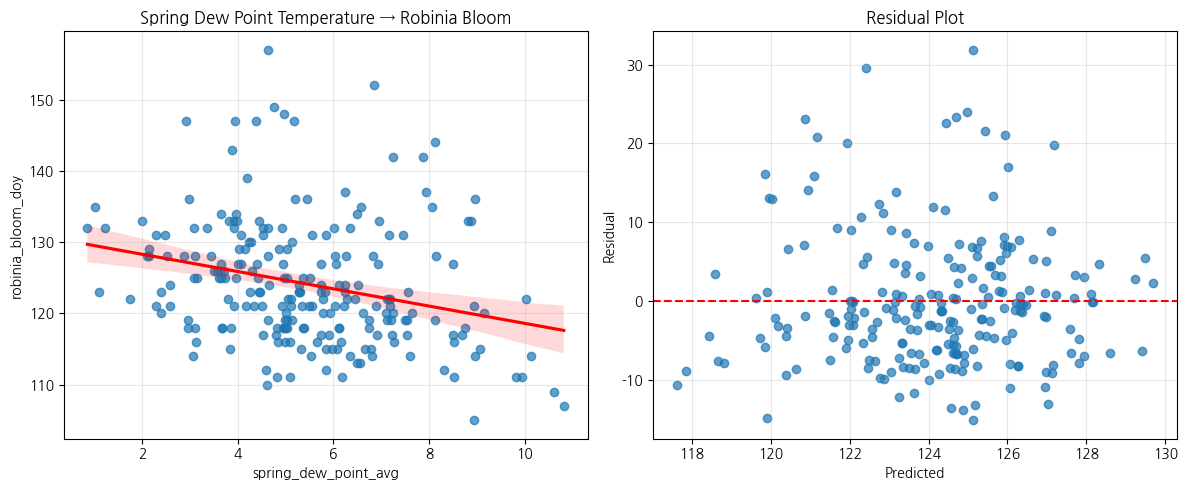

In [ ]:
# 평균 이슬점온도 → 개화일
robinia_dew_model = regression_analysis(
    robinia_df,
    "spring_dew_point_avg",
    "robinia_bloom_doy",
    "Spring Dew Point Temperature → Robinia Bloom"
)

Spring Minimum Relative Humidity → Robinia Bloom
회귀식
robinia_bloom_doy = 114.244 + (0.252) × spring_humidity_min

회귀계수(beta): 0.252
절편(intercept): 114.244
R² : 0.055
MAE : 6.690
RMSE : 8.431

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     12.97
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           0.000390
Time:                        03:09:22   Log-Likelihood:                -795.39
No. Observations:                 224   AIC:                             1595.
Df Residuals:                     222   BIC:                             1602.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
       

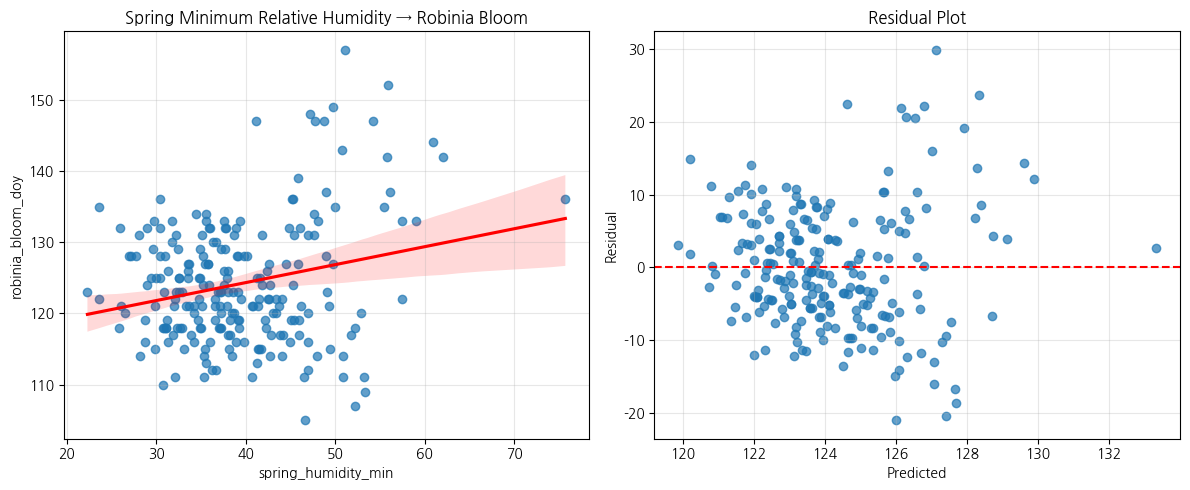

In [ ]:
# 최소 상대습도 → 개화일
robinia_min_model = regression_analysis(
    robinia_df,
    "spring_humidity_min",
    "robinia_bloom_doy",
    "Spring Minimum Relative Humidity → Robinia Bloom"
)

Spring Average Relative Humidity → Robinia Bloom
회귀식
robinia_bloom_doy = 99.079 + (0.395) × spring_humidity_avg

회귀계수(beta): 0.395
절편(intercept): 99.079
R² : 0.111
MAE : 6.420
RMSE : 8.179

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     27.69
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.34e-07
Time:                        03:09:22   Log-Likelihood:                -788.58
No. Observations:                 224   AIC:                             1581.
Df Residuals:                     222   BIC:                             1588.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
         

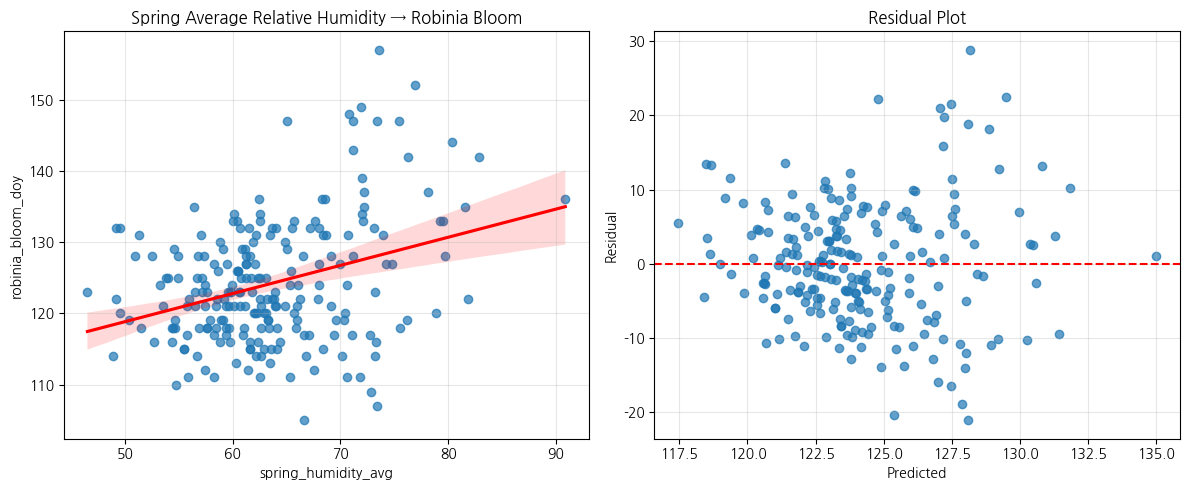

In [ ]:
# 평균 상대습도 → 개화일
robinia_avg_model = regression_analysis(
    robinia_df,
    "spring_humidity_avg",
    "robinia_bloom_doy",
    "Spring Average Relative Humidity → Robinia Bloom"
)

Spring Aaverage vapor pressure → Robinia Bloom
회귀식
robinia_bloom_doy = 145.823 + (-2.185) × spring_vapor_pressure_avg

회귀계수(beta): -2.185
절편(intercept): 145.823
R² : 0.098
MAE : 6.187
RMSE : 8.238

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     24.12
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.76e-06
Time:                        03:09:23   Log-Likelihood:                -790.20
No. Observations:                 224   AIC:                             1584.
Df Residuals:                     222   BIC:                             1591.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
 

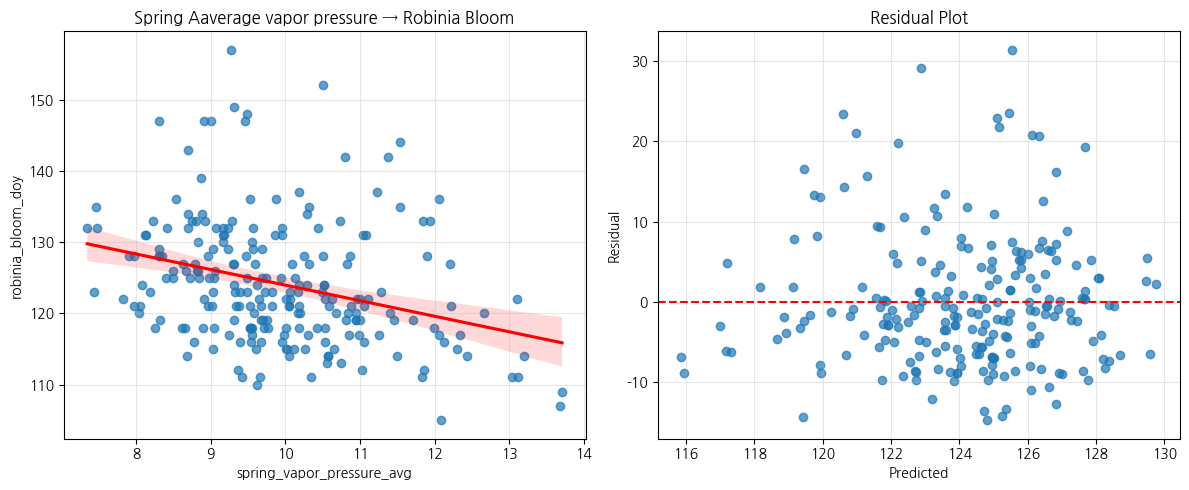

In [ ]:
# 평균 증기압 → 개화일
robinia_vapor_model = regression_analysis(
    robinia_df,
    "spring_vapor_pressure_avg",
    "robinia_bloom_doy",
    "Spring Aaverage vapor pressure → Robinia Bloom"
)

# 벚나무

Spring Temperature → Cherry Bloom
회귀식
cherry_bloom_doy = 138.637 + (-3.703) × spring_temp_avg

회귀계수(beta): -3.703
절편(intercept): 138.637
R² : 0.560
MAE : 3.573
RMSE : 4.422

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     285.9
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           6.02e-42
Time:                        03:09:23   Log-Likelihood:                -659.56
No. Observations:                 227   AIC:                             1323.
Df Residuals:                     225   BIC:                             1330.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coe

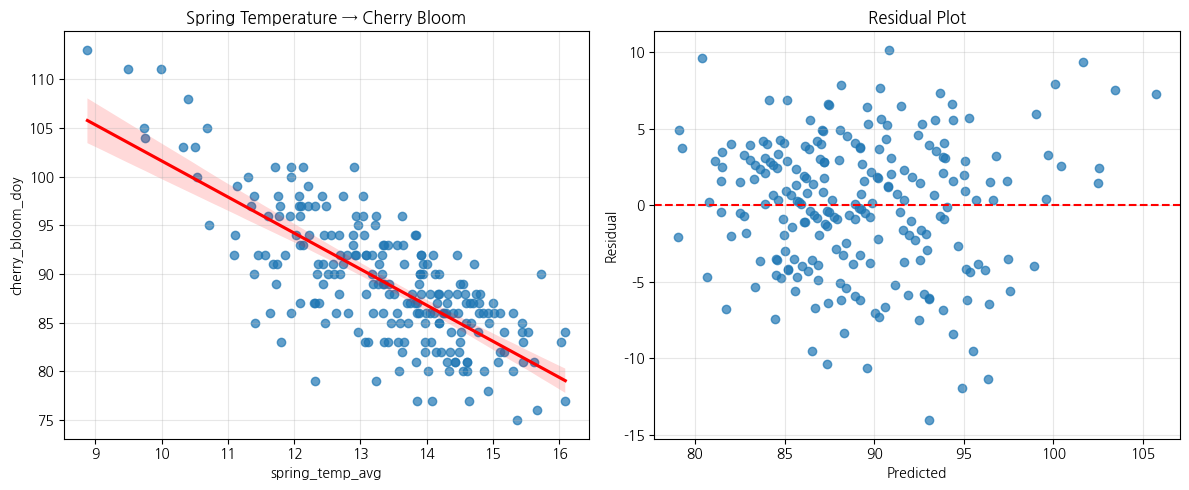

In [ ]:
## 벚나무 회귀분석
# 평균기온 → 개화일
cherry_temp_model = regression_analysis(
    cherry_df,
    "spring_temp_avg",
    "cherry_bloom_doy",
    "Spring Temperature → Cherry Bloom"
)

Accumulated Temperature → Cherry Bloom
회귀식
cherry_bloom_doy = 116.169 + (-0.033) × accumulated_temp

회귀계수(beta): -0.033
절편(intercept): 116.169
R² : 0.542
MAE : 3.649
RMSE : 4.509

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     266.4
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.89e-40
Time:                        03:09:24   Log-Likelihood:                -663.98
No. Observations:                 227   AIC:                             1332.
Df Residuals:                     225   BIC:                             1339.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   

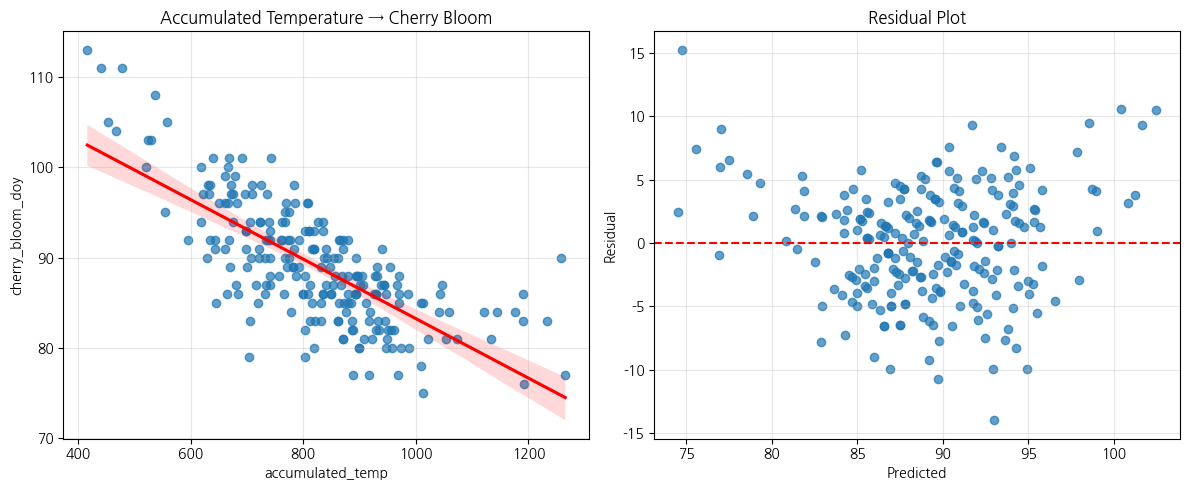

In [ ]:
# 적산온도 → 개화일
cherry_gdd_model = regression_analysis(
    cherry_df,
    "accumulated_temp",
    "cherry_bloom_doy",
    "Accumulated Temperature → Cherry Bloom"
)

Spring Rainfall → Cherry Bloom
회귀식
cherry_bloom_doy = 93.890 + (-0.019) × spring_rainfall

회귀계수(beta): -0.019
절편(intercept): 93.890
R² : 0.119
MAE : 4.976
RMSE : 6.255

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     30.38
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           9.68e-08
Time:                        03:09:24   Log-Likelihood:                -738.27
No. Observations:                 227   AIC:                             1481.
Df Residuals:                     225   BIC:                             1487.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    

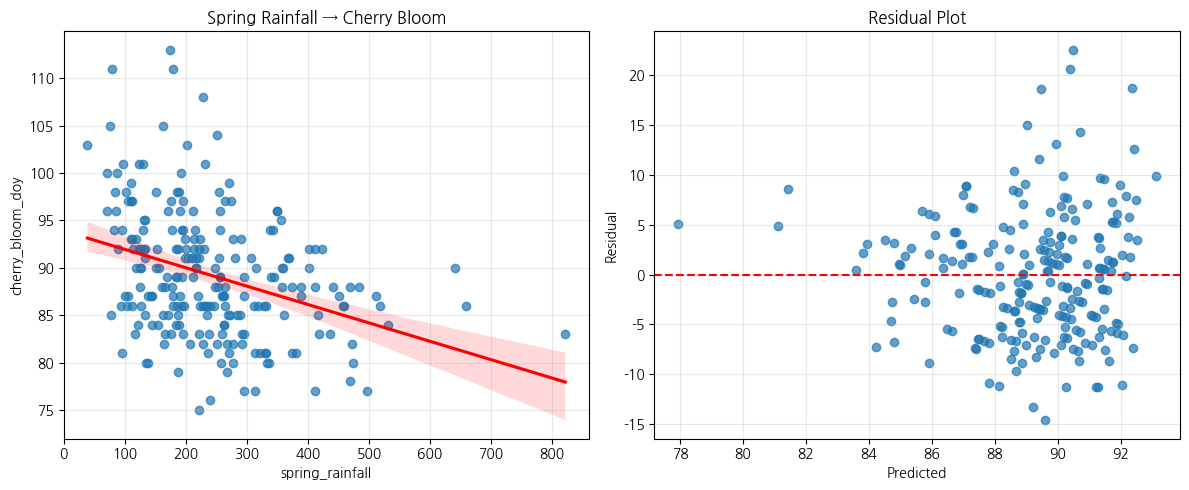

In [ ]:
# 강수량 → 개화일
cherry_rain_model = regression_analysis(
    cherry_df,
    "spring_rainfall",
    "cherry_bloom_doy",
    "Spring Rainfall → Cherry Bloom"
)

Spring Dew Point Temperature → Cherry Bloom
회귀식
cherry_bloom_doy = 94.638 + (-0.995) × spring_dew_point_avg

회귀계수(beta): -0.995
절편(intercept): 94.638
R² : 0.088
MAE : 4.851
RMSE : 6.364

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     21.72
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           5.41e-06
Time:                        03:09:25   Log-Likelihood:                -742.19
No. Observations:                 227   AIC:                             1488.
Df Residuals:                     225   BIC:                             1495.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
            

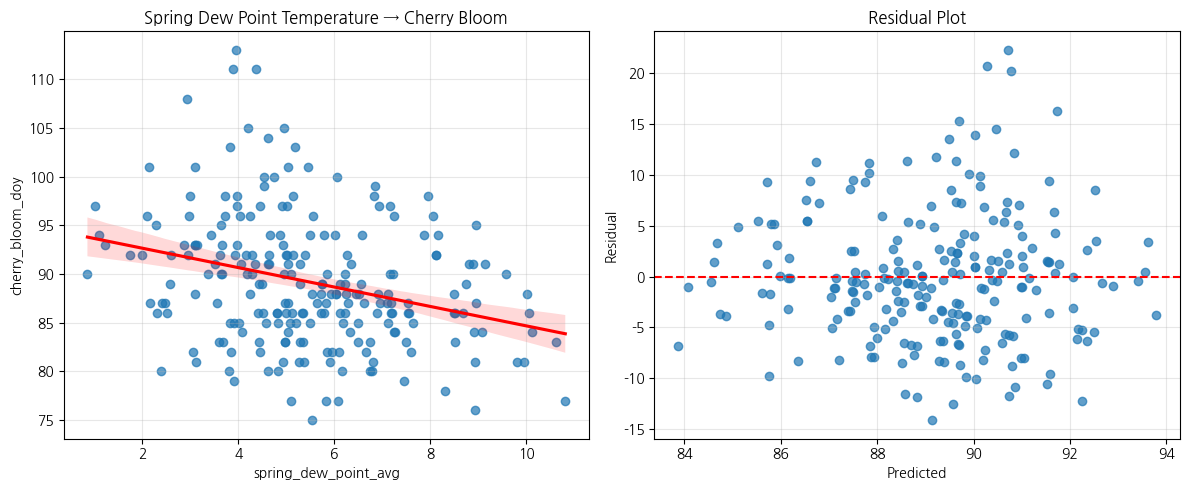

In [ ]:
# 평균 이슬점온도 → 개화일
cherry_dew_model = regression_analysis(
    cherry_df,
    "spring_dew_point_avg",
    "cherry_bloom_doy",
    "Spring Dew Point Temperature → Cherry Bloom"
)

Spring Minimum Relative Humidity → Cherry Bloom
회귀식
cherry_bloom_doy = 86.797 + (0.061) × spring_humidity_min

회귀계수(beta): 0.061
절편(intercept): 86.797
R² : 0.005
MAE : 5.248
RMSE : 6.646

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.234
Date:                Thu, 20 Aug 2026   Prob (F-statistic):              0.268
Time:                        03:09:26   Log-Likelihood:                -752.03
No. Observations:                 227   AIC:                             1508.
Df Residuals:                     225   BIC:                             1515.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
           

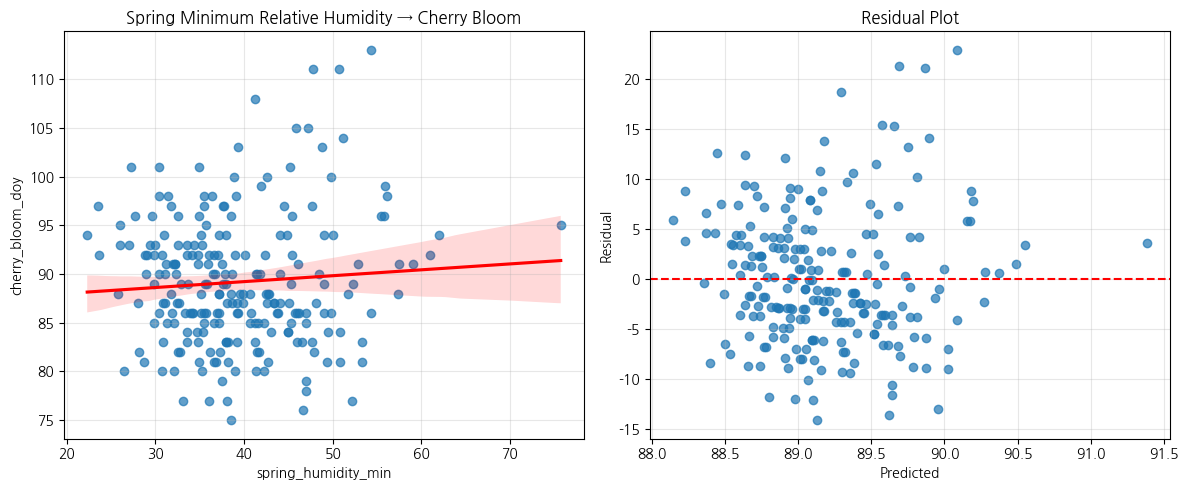

In [ ]:
# 최소 상대습도 → 개화일
cherry_min_model = regression_analysis(
    cherry_df,
    "spring_humidity_min",
    "cherry_bloom_doy",
    "Spring Minimum Relative Humidity → Cherry Bloom"
)

Spring Average Relative Humidity → Cherry Bloom
회귀식
cherry_bloom_doy = 76.131 + (0.205) × spring_humidity_avg

회귀계수(beta): 0.205
절편(intercept): 76.131
R² : 0.051
MAE : 5.137
RMSE : 6.492

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     12.09
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           0.000608
Time:                        03:09:26   Log-Likelihood:                -746.71
No. Observations:                 227   AIC:                             1497.
Df Residuals:                     225   BIC:                             1504.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
           

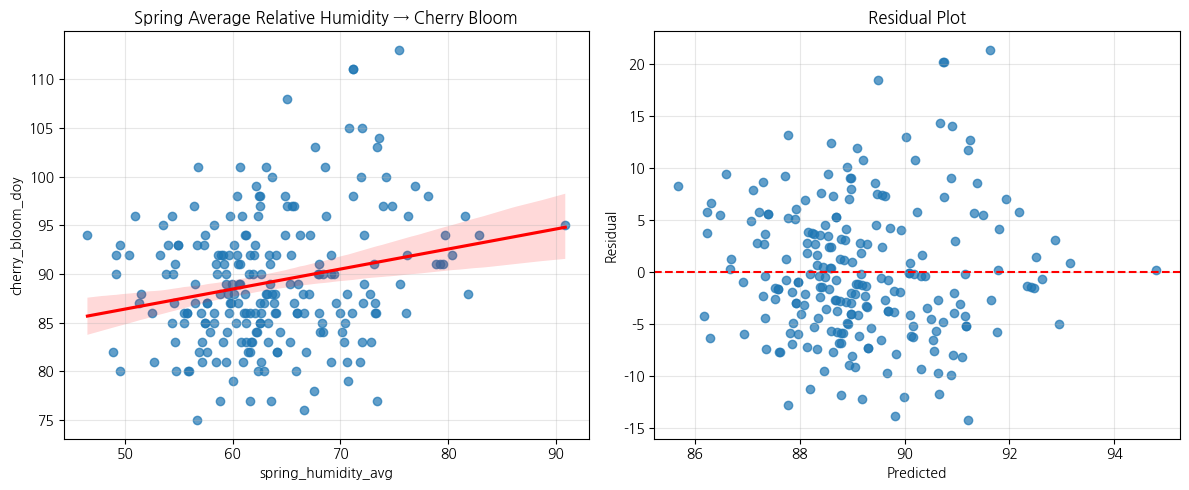

In [ ]:
# 평균 상대습도 → 개화일
cherry_avg_model = regression_analysis(
    cherry_df,
    "spring_humidity_avg",
    "cherry_bloom_doy",
    "Spring Average Relative Humidity → Cherry Bloom"
)

Spring Aaverage vapor pressure → Cherry Bloom
회귀식
cherry_bloom_doy = 105.962 + (-1.685) × spring_vapor_pressure_avg

회귀계수(beta): -1.685
절편(intercept): 105.962
R² : 0.105
MAE : 4.820
RMSE : 6.305

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     26.36
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           6.13e-07
Time:                        03:09:27   Log-Likelihood:                -740.07
No. Observations:                 227   AIC:                             1484.
Df Residuals:                     225   BIC:                             1491.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
   

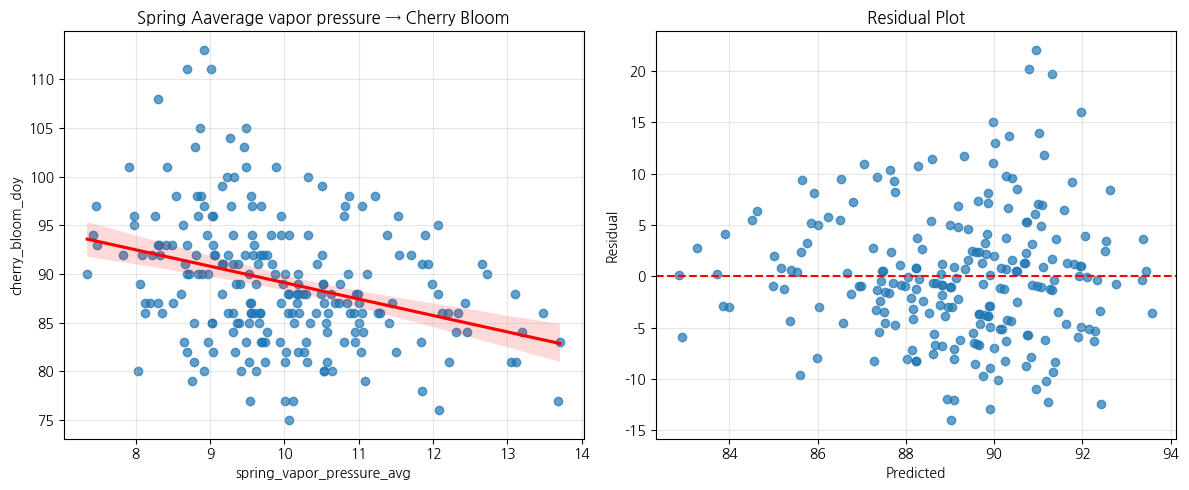

In [ ]:
# 평균 증기압 → 개화일
cherry_vapor_model = regression_analysis(
    cherry_df,
    "spring_vapor_pressure_avg",
    "cherry_bloom_doy",
    "Spring Aaverage vapor pressure → Cherry Bloom"
)

# time-lag

Spring Temperature → Robinia Time-lag
회귀식
robinia_time_lag = -7.693 + (4.342) × spring_temp_avg

회귀계수(beta): 4.342
절편(intercept): -7.693
R² : 0.126
MAE : 11.509
RMSE : 15.226

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     32.12
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.48e-08
Time:                        03:09:27   Log-Likelihood:                -927.80
No. Observations:                 224   AIC:                             1860.
Df Residuals:                     222   BIC:                             1866.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      c

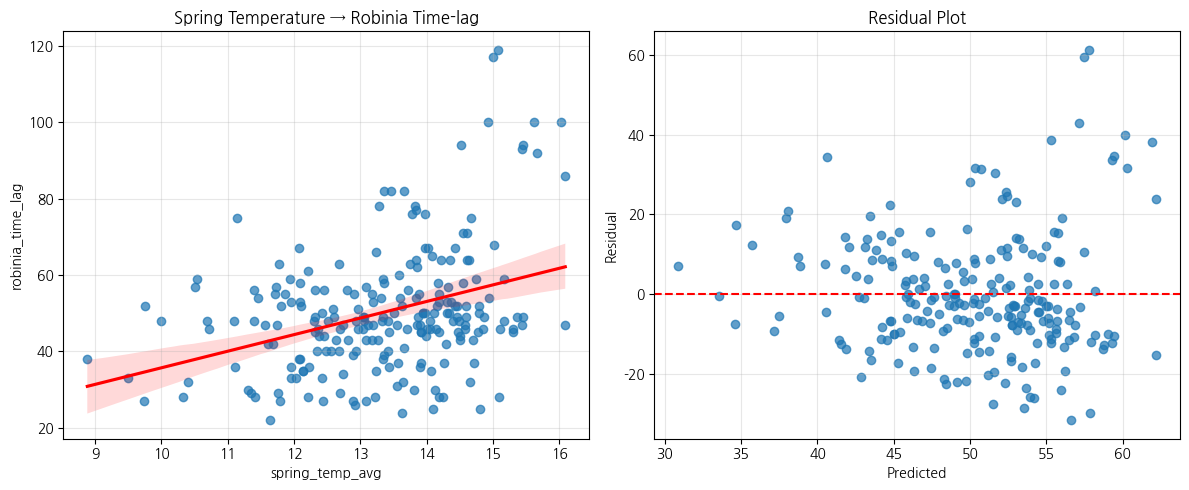

Accumulated Temperature → Robinia Time-lag
회귀식
robinia_time_lag = 5.706 + (0.055) × accumulated_temp

회귀계수(beta): 0.055
절편(intercept): 5.706
R² : 0.230
MAE : 11.080
RMSE : 14.297

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     66.23
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.86e-14
Time:                        03:09:27   Log-Likelihood:                -913.69
No. Observations:                 224   AIC:                             1831.
Df Residuals:                     222   BIC:                             1838.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   

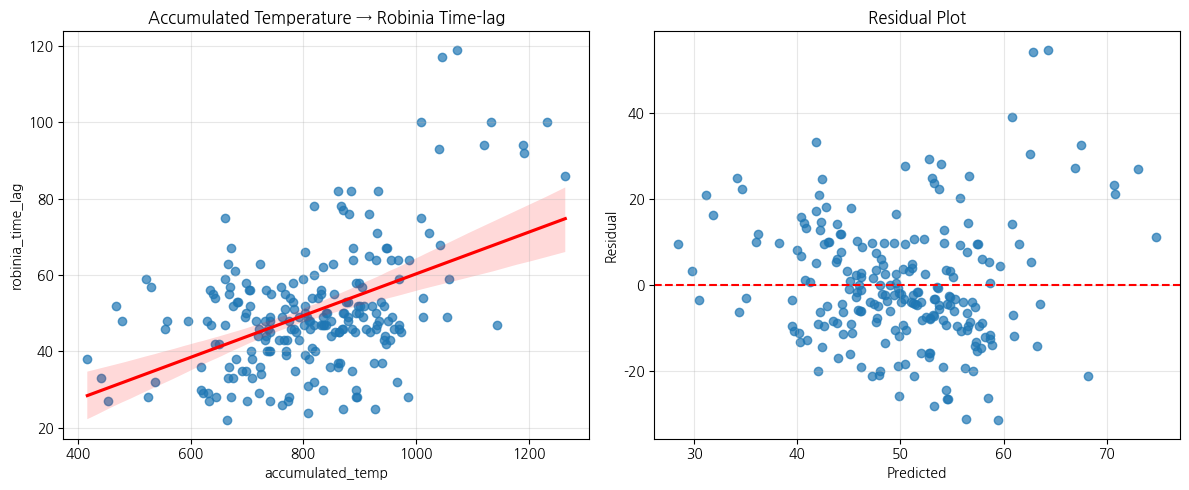

Spring Rainfall → Robinia Time-lag
회귀식
robinia_time_lag = 38.460 + (0.049) × spring_rainfall

회귀계수(beta): 0.049
절편(intercept): 38.460
R² : 0.118
MAE : 11.147
RMSE : 15.302

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     29.60
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.40e-07
Time:                        03:09:28   Log-Likelihood:                -928.91
No. Observations:                 224   AIC:                             1862.
Df Residuals:                     222   BIC:                             1869.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef

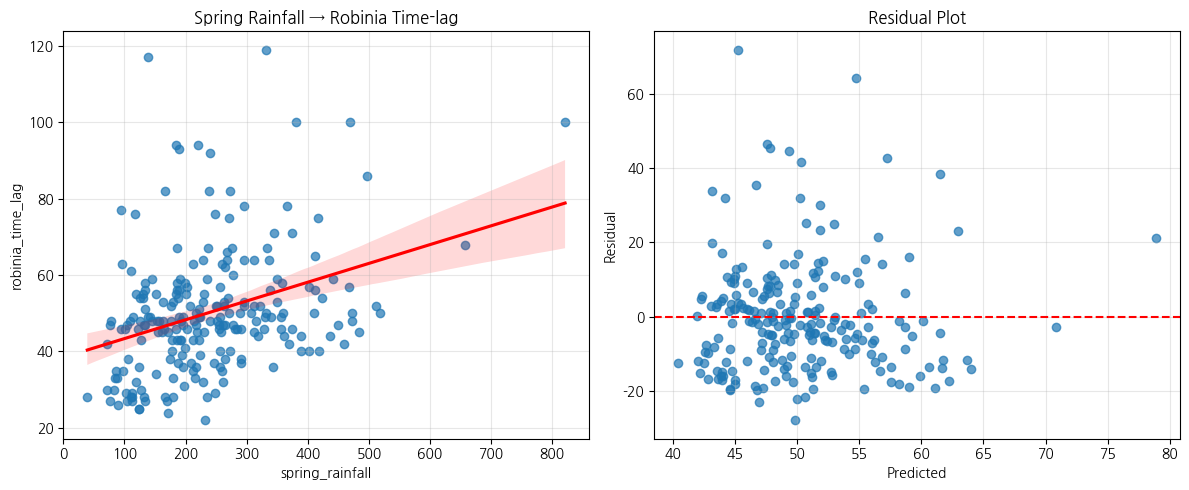

Spring Dew Point Temperature → Robinia Time-lag
회귀식
robinia_time_lag = 30.971 + (3.541) × spring_dew_point_avg

회귀계수(beta): 3.541
절편(intercept): 30.971
R² : 0.178
MAE : 11.202
RMSE : 14.766

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     48.21
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.18e-11
Time:                        03:09:28   Log-Likelihood:                -920.92
No. Observations:                 224   AIC:                             1846.
Df Residuals:                     222   BIC:                             1853.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
        

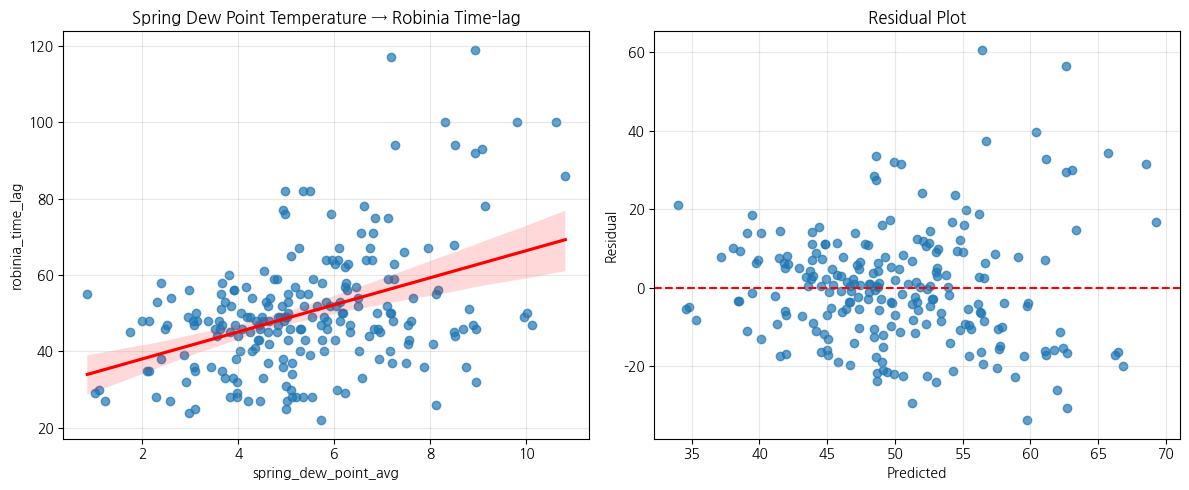

Spring Minimum Relative Humidity → Robinia Time-lag
회귀식
robinia_time_lag = 25.853 + (0.619) × spring_humidity_min

회귀계수(beta): 0.619
절편(intercept): 25.853
R² : 0.094
MAE : 11.163
RMSE : 15.502

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     23.16
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.75e-06
Time:                        03:09:29   Log-Likelihood:                -931.81
No. Observations:                 224   AIC:                             1868.
Df Residuals:                     222   BIC:                             1874.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
     

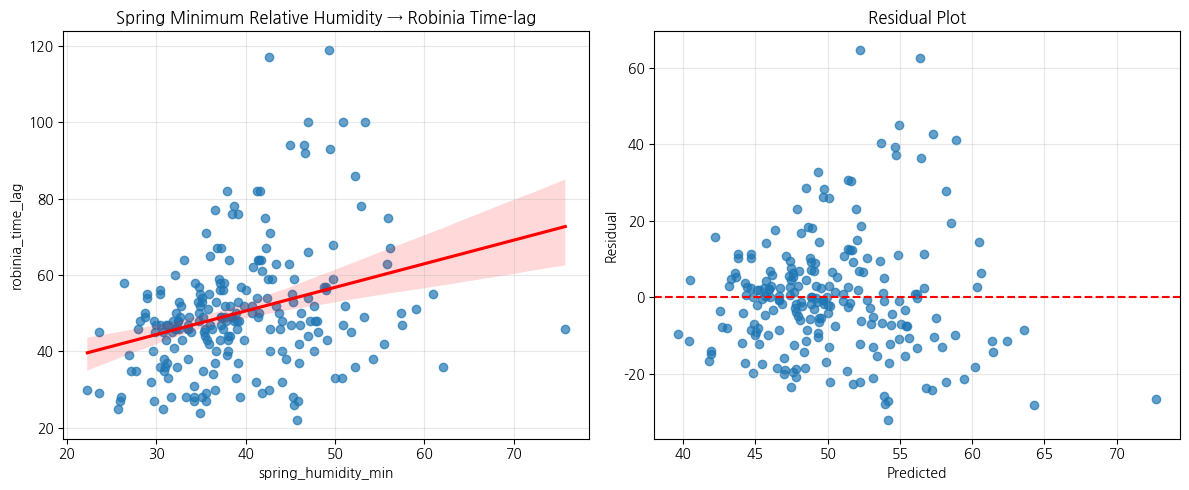

Spring Average Relative Humidity → Robinia Time-lag
회귀식
robinia_time_lag = 29.958 + (0.319) × spring_humidity_avg

회귀계수(beta): 0.319
절편(intercept): 29.958
R² : 0.020
MAE : 11.433
RMSE : 16.123

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.639
Date:                Thu, 20 Aug 2026   Prob (F-statistic):             0.0323
Time:                        03:09:29   Log-Likelihood:                -940.61
No. Observations:                 224   AIC:                             1885.
Df Residuals:                     222   BIC:                             1892.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
     

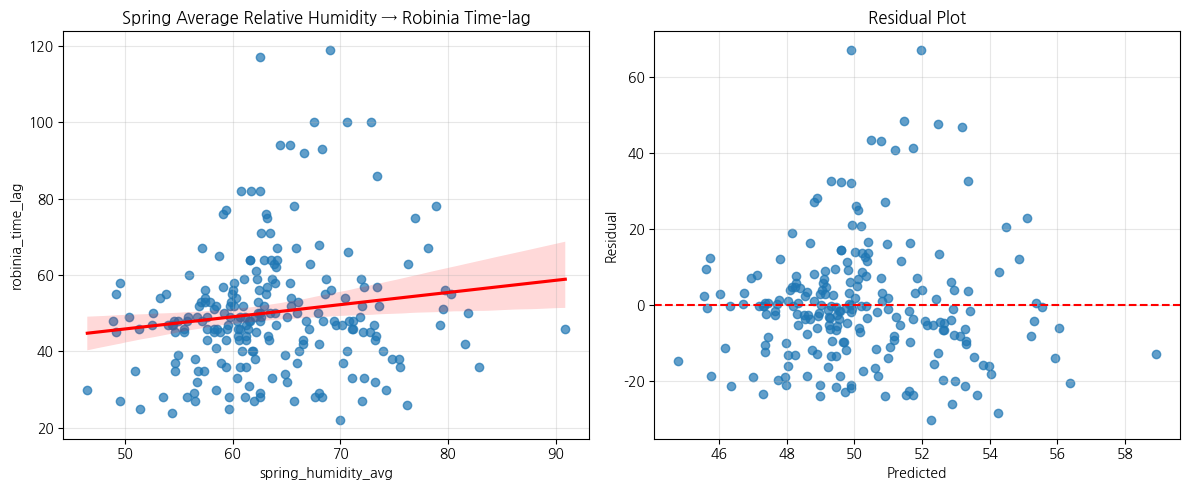

Spring Aaverage vapor pressure → Robinia Time-lag
회귀식
robinia_time_lag = -5.439 + (5.608) × spring_vapor_pressure_avg

회귀계수(beta): 5.608
절편(intercept): -5.439
R² : 0.183
MAE : 11.198
RMSE : 14.725

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     49.70
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.24e-11
Time:                        03:09:30   Log-Likelihood:                -920.30
No. Observations:                 224   AIC:                             1845.
Df Residuals:                     222   BIC:                             1851.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
 

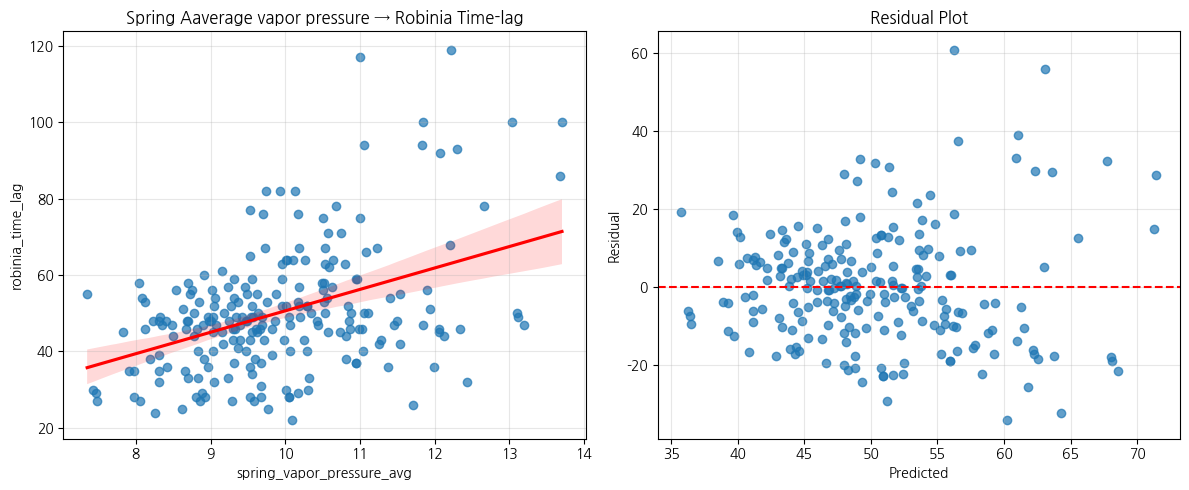

In [ ]:
## Time-lag 회귀분석
# 아까시
lag_robinia_temp_model = regression_analysis(
    robinia_df,
    "spring_temp_avg",
    "robinia_time_lag",
    "Spring Temperature → Robinia Time-lag"
)

lag_robinia_gdd_model = regression_analysis(
    robinia_df,
    "accumulated_temp",
    "robinia_time_lag",
    "Accumulated Temperature → Robinia Time-lag"
)

lag_robinia_rain_model = regression_analysis(
    robinia_df,
    "spring_rainfall",
    "robinia_time_lag",
    "Spring Rainfall → Robinia Time-lag"
)

lag_robinia_dew_model = regression_analysis(
    robinia_df,
    "spring_dew_point_avg",
    "robinia_time_lag",
    "Spring Dew Point Temperature → Robinia Time-lag"
)

lag_robinia_min_model = regression_analysis(
    robinia_df,
    "spring_humidity_min",
    "robinia_time_lag",
    "Spring Minimum Relative Humidity → Robinia Time-lag"
)

lag_robinia_avg_model = regression_analysis(
    robinia_df,
    "spring_humidity_avg",
    "robinia_time_lag",
    "Spring Average Relative Humidity → Robinia Time-lag"
)

lag_robinia_vapor_model = regression_analysis(
    robinia_df,
    "spring_vapor_pressure_avg",
    "robinia_time_lag",
    "Spring Aaverage vapor pressure → Robinia Time-lag"
)

Spring Temperature → Cherry Time-lag
회귀식
cherry_time_lag = -73.038 + (6.651) × spring_temp_avg

회귀계수(beta): 6.651
절편(intercept): -73.038
R² : 0.269
MAE : 10.962
RMSE : 14.754

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     82.87
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.84e-17
Time:                        03:09:31   Log-Likelihood:                -933.08
No. Observations:                 227   AIC:                             1870.
Df Residuals:                     225   BIC:                             1877.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      c

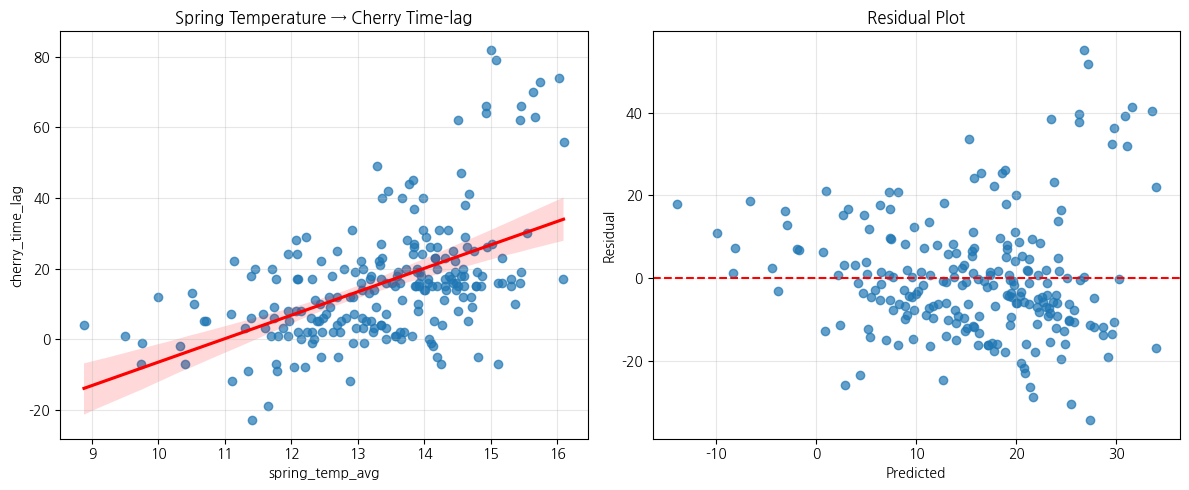

Accumulated Temperature → Cherry Time-lag
회귀식
cherry_time_lag = -44.184 + (0.073) × accumulated_temp

회귀계수(beta): 0.073
절편(intercept): -44.184
R² : 0.399
MAE : 10.302
RMSE : 13.377

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     149.5
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.06e-26
Time:                        03:09:31   Log-Likelihood:                -910.84
No. Observations:                 227   AIC:                             1826.
Df Residuals:                     225   BIC:                             1833.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 

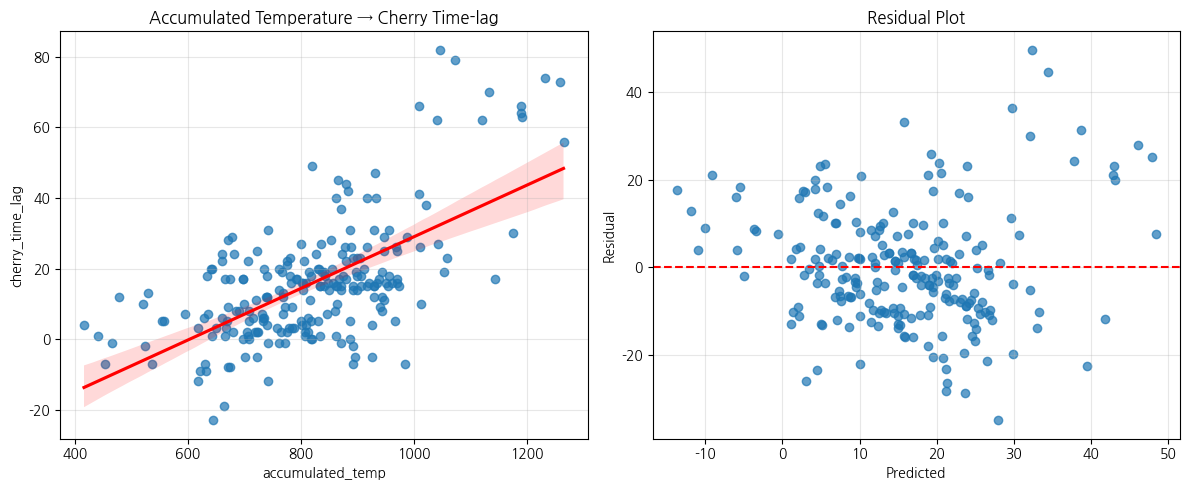

Spring Rainfall → Cherry Time-lag
회귀식
cherry_time_lag = 2.023 + (0.057) × spring_rainfall

회귀계수(beta): 0.057
절편(intercept): 2.023
R² : 0.152
MAE : 11.320
RMSE : 15.895

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     40.28
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.20e-09
Time:                        03:09:31   Log-Likelihood:                -949.98
No. Observations:                 227   AIC:                             1904.
Df Residuals:                     225   BIC:                             1911.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    

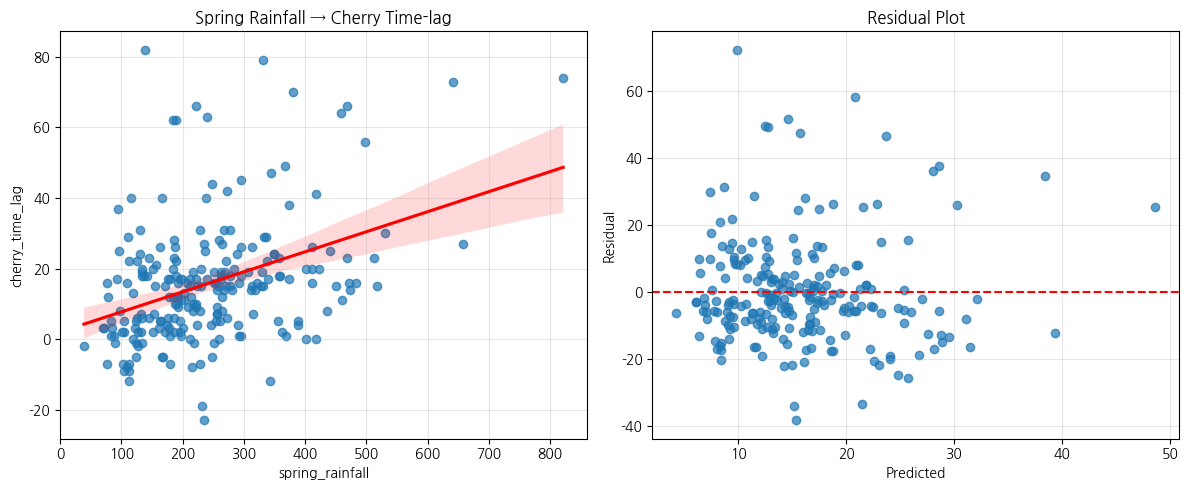

Spring Dew Point Temperature → Cherry Time-lag
회귀식
cherry_time_lag = -6.649 + (4.095) × spring_dew_point_avg

회귀계수(beta): 4.095
절편(intercept): -6.649
R² : 0.222
MAE : 11.408
RMSE : 15.221

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     64.28
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           5.86e-14
Time:                        03:09:32   Log-Likelihood:                -940.15
No. Observations:                 227   AIC:                             1884.
Df Residuals:                     225   BIC:                             1891.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
          

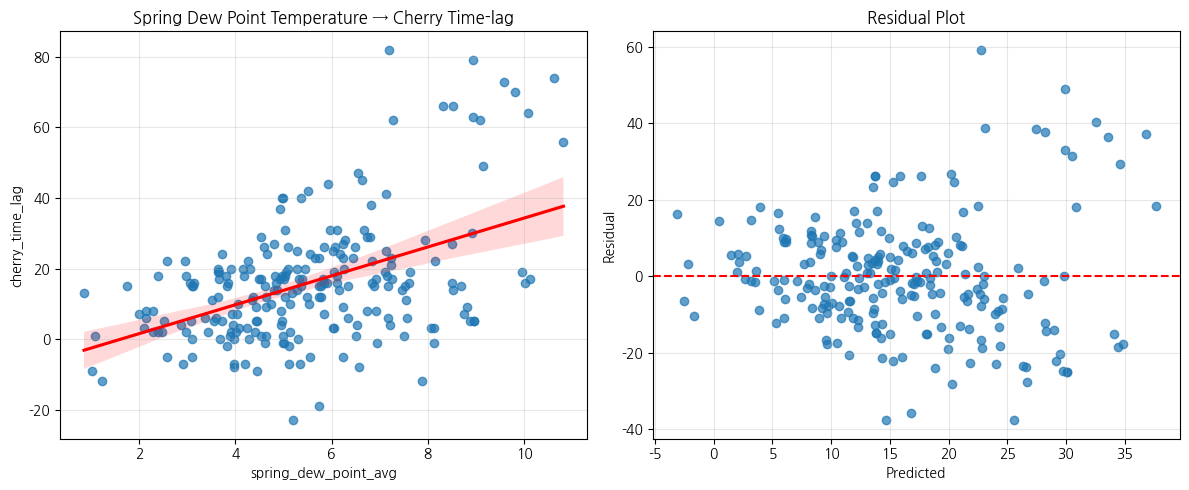

Spring Minimum Relative Humidity → Cherry Time-lag
회귀식
cherry_time_lag = -4.433 + (0.513) × spring_humidity_min

회귀계수(beta): 0.513
절편(intercept): -4.433
R² : 0.058
MAE : 12.100
RMSE : 16.748

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     13.93
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           0.000240
Time:                        03:09:32   Log-Likelihood:                -961.85
No. Observations:                 227   AIC:                             1928.
Df Residuals:                     225   BIC:                             1935.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
       

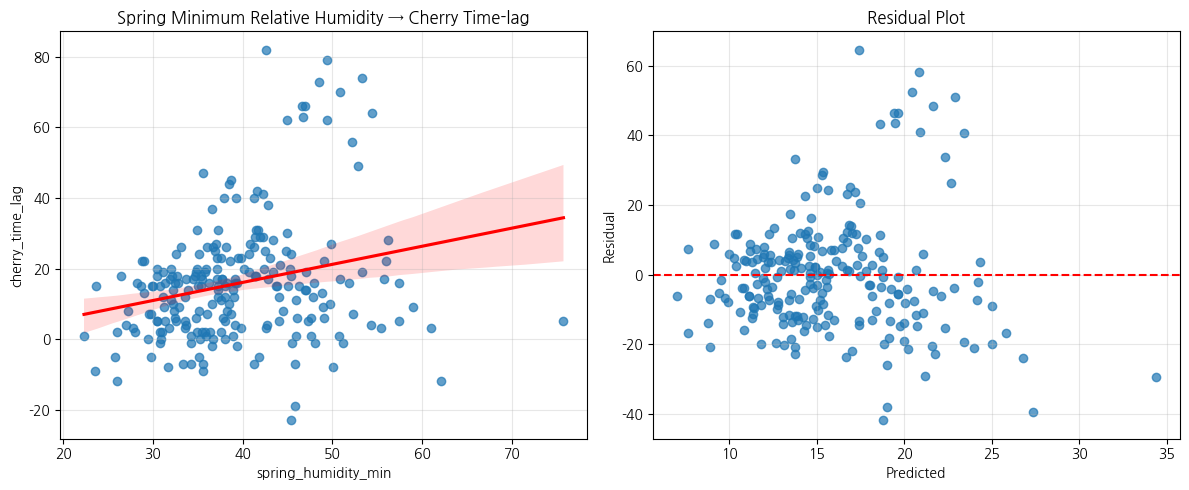

Spring Average Relative Humidity → Cherry Time-lag
회귀식
cherry_time_lag = 1.981 + (0.217) × spring_humidity_avg

회귀계수(beta): 0.217
절편(intercept): 1.981
R² : 0.009
MAE : 12.178
RMSE : 17.185

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.931
Date:                Thu, 20 Aug 2026   Prob (F-statistic):              0.166
Time:                        03:09:33   Log-Likelihood:                -967.70
No. Observations:                 227   AIC:                             1939.
Df Residuals:                     225   BIC:                             1946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
         

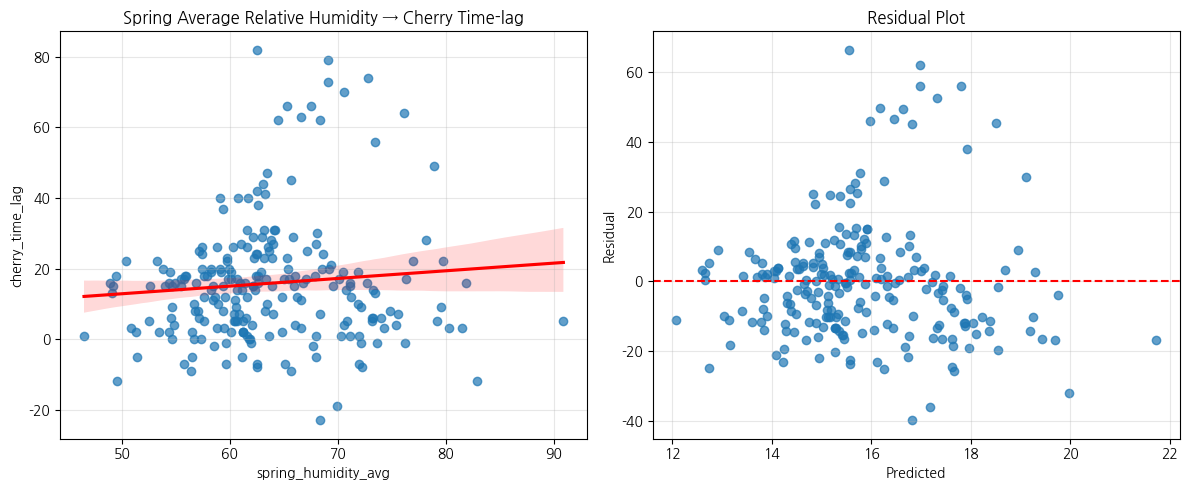

Spring Aaverage vapor pressure → Cherry Time-lag
회귀식
cherry_time_lag = -49.933 + (6.600) × spring_vapor_pressure_avg

회귀계수(beta): 6.600
절편(intercept): -49.933
R² : 0.240
MAE : 11.375
RMSE : 15.047

[통계 검정 결과]
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     71.02
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.23e-15
Time:                        03:09:34   Log-Likelihood:                -937.53
No. Observations:                 227   AIC:                             1879.
Df Residuals:                     225   BIC:                             1886.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
 

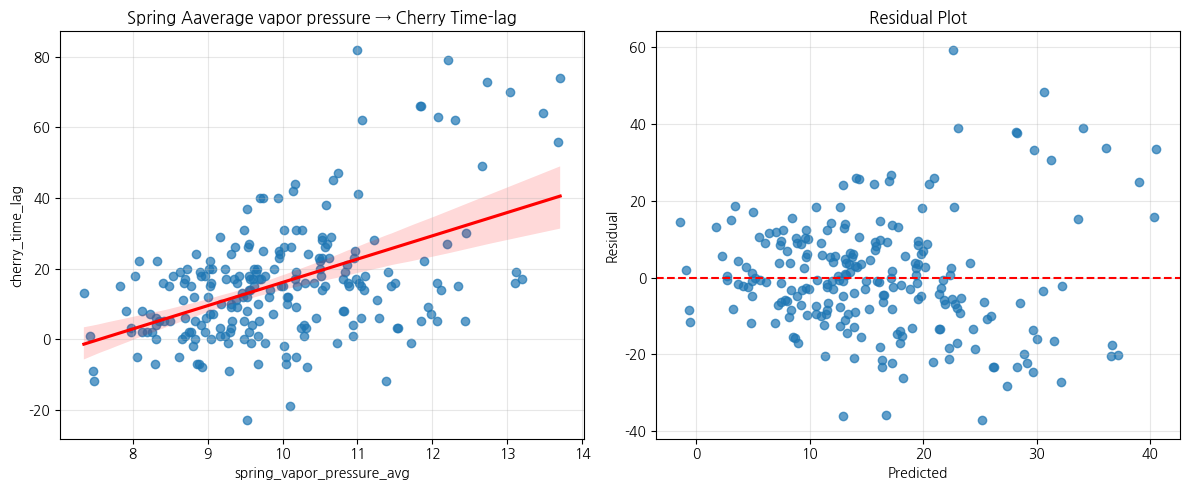

In [ ]:
# 벚나무
lag_cherry_temp_model = regression_analysis(
    cherry_df,
    "spring_temp_avg",
    "cherry_time_lag",
    "Spring Temperature → Cherry Time-lag"
)

lag_cherry_gdd_model = regression_analysis(
    cherry_df,
    "accumulated_temp",
    "cherry_time_lag",
    "Accumulated Temperature → Cherry Time-lag"
)

lag_cherry_rain_model = regression_analysis(
    cherry_df,
    "spring_rainfall",
    "cherry_time_lag",
    "Spring Rainfall → Cherry Time-lag"
)

lag_cherry_dew_model = regression_analysis(
    cherry_df,
    "spring_dew_point_avg",
    "cherry_time_lag",
    "Spring Dew Point Temperature → Cherry Time-lag"
)

lag_cherry_min_model = regression_analysis(
    cherry_df,
    "spring_humidity_min",
    "cherry_time_lag",
    "Spring Minimum Relative Humidity → Cherry Time-lag"
)

lag_cherry_avg_model = regression_analysis(
    cherry_df,
    "spring_humidity_avg",
    "cherry_time_lag",
    "Spring Average Relative Humidity → Cherry Time-lag"
)

lag_cherry_vapor_model = regression_analysis(
    cherry_df,
    "spring_vapor_pressure_avg",
    "cherry_time_lag",
    "Spring Aaverage vapor pressure → Cherry Time-lag"
)

# 다중선형회귀

## Time-lag

### 평균기온

In [ ]:
# 아까시
m_acacia_temp = multiple_regression(
    master_df,
    ["spring_temp_avg","bee_start_doy"],
    "acacia_time_lag",
    "Acacia Time-lag (Temp + Bee)"
)

KeyError: "['acacia_time_lag'] not in index"

In [ ]:
# 벚나무
m_cherry_temp = multiple_regression(
    master_df,
    ["spring_temp_avg","bee_start_doy"],
    "cherry_time_lag",
    "Cherry Time-lag (Temp + Bee)"
)

### 적산온도

In [ ]:
# 아까시
m_acacia_gdd = multiple_regression(
    master_df,
    ["accumulated_temp","bee_start_doy"],
    "acacia_time_lag",
    "Acacia Time-lag (GDD + Bee)"
)

In [ ]:
# 벚나무
m_cherry_gdd = multiple_regression(
    master_df,
    ["accumulated_temp","bee_start_doy"],
    "cherry_time_lag",
    "Cherry Time-lag (GDD + Bee)"
)

## bloom

### 평균기온

In [ ]:
# 아까시
multiple_regression(
    master_df,
    ["spring_temp_avg","bee_start_doy"],
    "acacia_bloom_doy",
    "Temp + Bee → Acacia Bloom"
)

In [ ]:
# 벚나무
multiple_regression(
    master_df,
    ["spring_temp_avg","bee_start_doy"],
    "cherry_bloom_doy",
    "Temp + Bee → Cherry Bloom"
)

### 적산온도

In [ ]:
# 아까시
multiple_regression(
    master_df,
    ["accumulated_temp","bee_start_doy"],
    "acacia_bloom_doy",
    "GDD + Bee → Acacia Bloom"
)

In [ ]:
# 벚나무
multiple_regression(
    master_df,
    ["accumulated_temp","bee_start_doy"],
    "cherry_bloom_doy",
    "GDD + Bee → Acacia Bloom"
)

## 추가독립변수



### 기온+강수량+습도변수

Robinia bloom doy A
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     191.1
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.17e-70
Time:                        04:14:27   Log-Likelihood:                -633.51
No. Observations:                 224   AIC:                             1277.
Df Residuals:                     219   BIC:                             1294.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

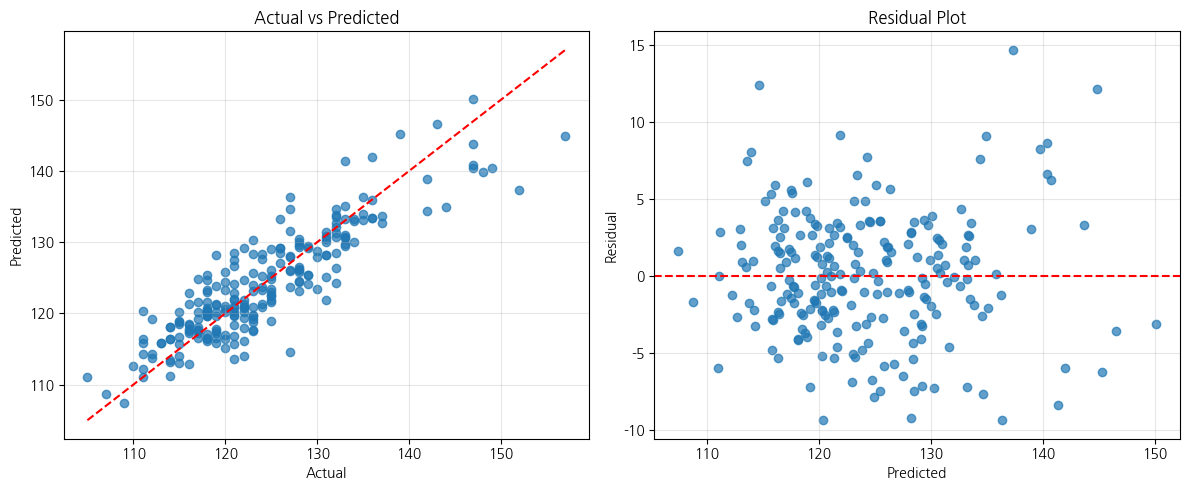

Robinia Time-lag A
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     28.63
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.14e-15
Time:                        04:14:29   Log-Likelihood:                -906.01
No. Observations:                 224   AIC:                             1820.
Df Residuals:                     220   BIC:                             1834.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const          

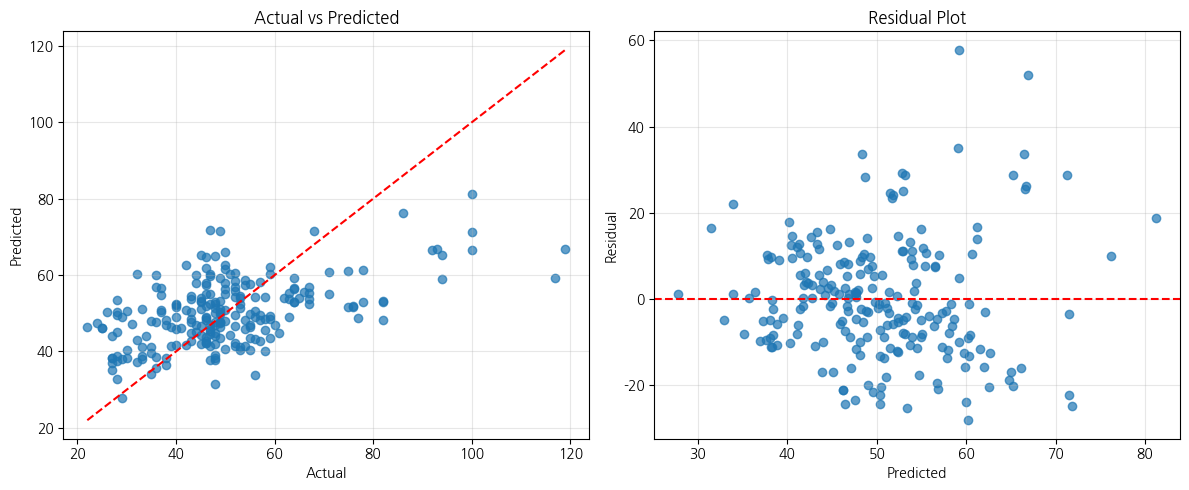

Robinia bloom doy B
                            OLS Regression Results                            
Dep. Variable:      robinia_bloom_doy   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     157.2
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.43e-63
Time:                        04:14:31   Log-Likelihood:                -650.12
No. Observations:                 224   AIC:                             1310.
Df Residuals:                     219   BIC:                             1327.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

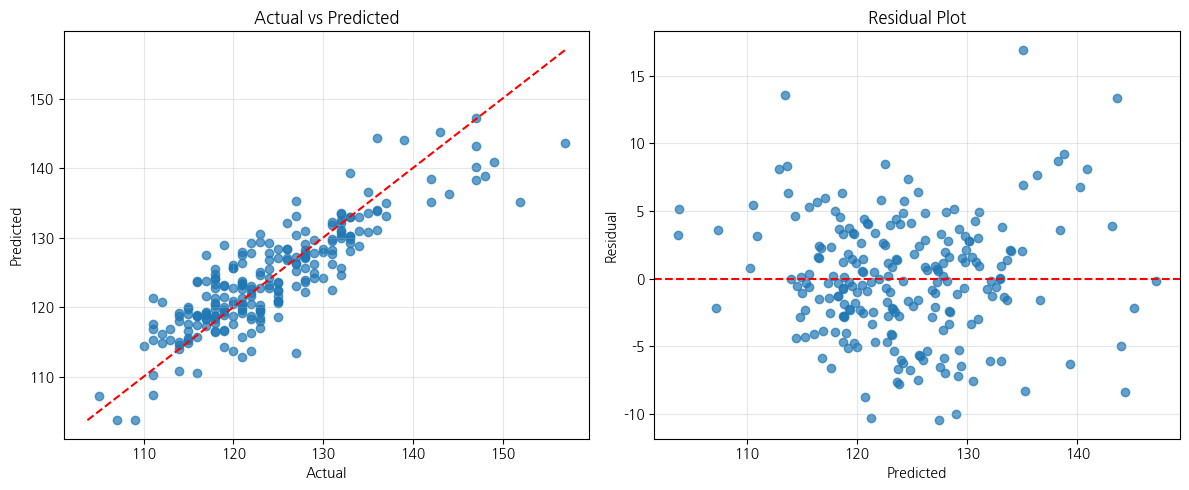

Robinia Time-lag B
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     39.09
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.75e-20
Time:                        04:14:32   Log-Likelihood:                -895.08
No. Observations:                 224   AIC:                             1798.
Df Residuals:                     220   BIC:                             1812.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const          

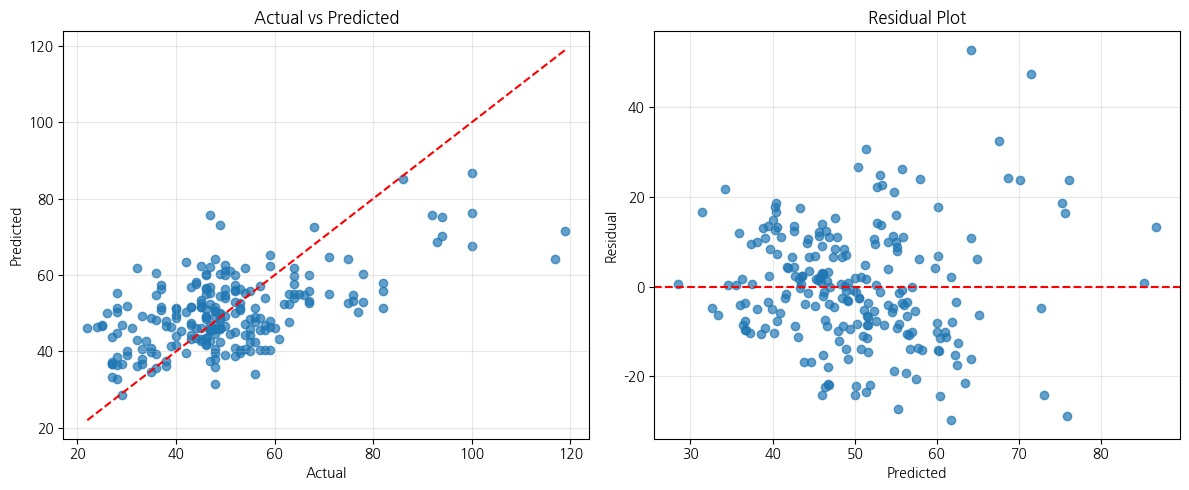

Cherry bloom doy A
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     85.91
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           9.09e-44
Time:                        04:14:33   Log-Likelihood:                -638.09
No. Observations:                 224   AIC:                             1286.
Df Residuals:                     219   BIC:                             1303.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const          

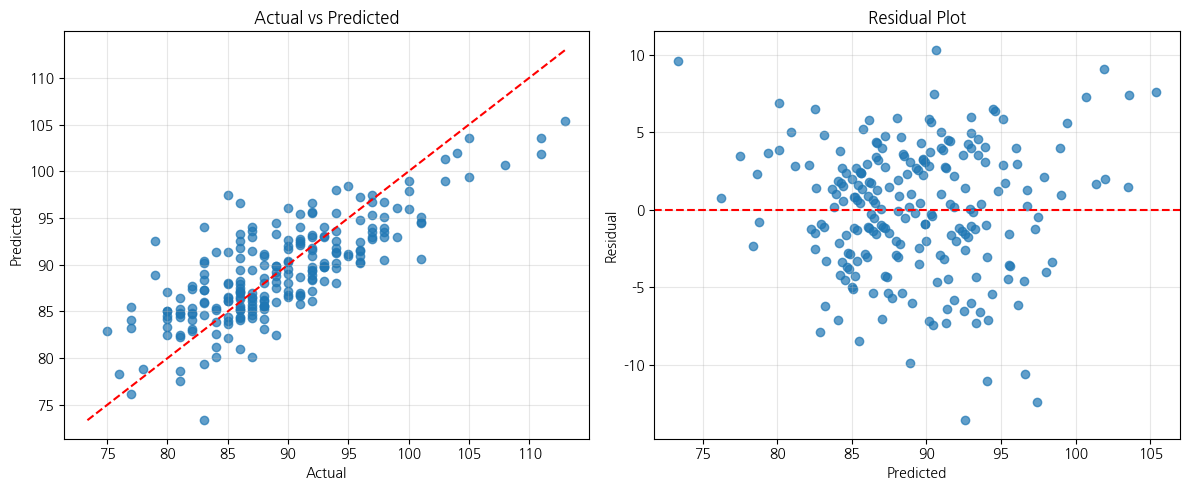

Cherry Time-lag A
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     40.42
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           7.59e-21
Time:                        04:14:34   Log-Likelihood:                -898.03
No. Observations:                 224   AIC:                             1804.
Df Residuals:                     220   BIC:                             1818.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const           

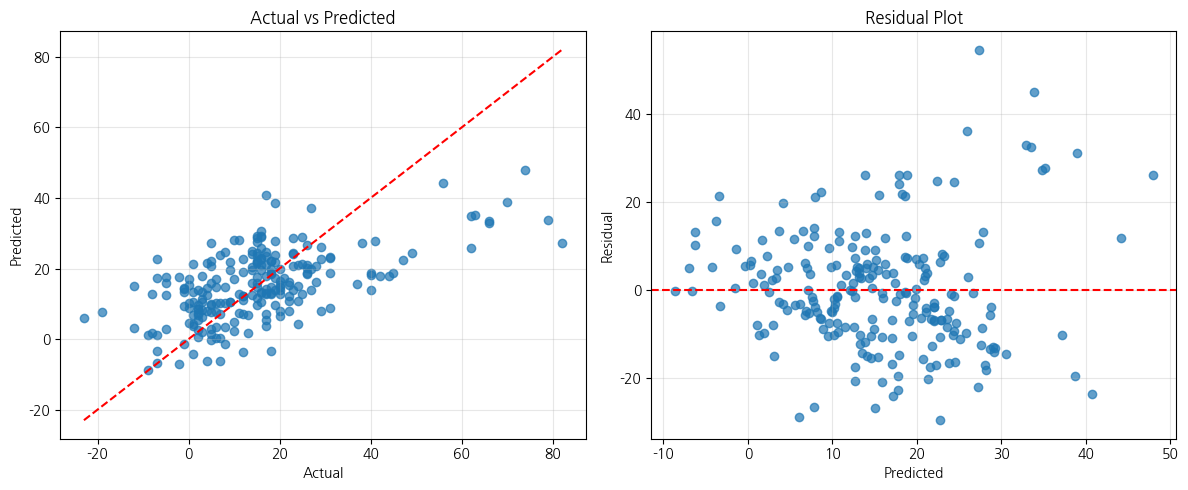

Cherry bloom doy B
                            OLS Regression Results                            
Dep. Variable:       cherry_bloom_doy   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     83.23
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           7.40e-43
Time:                        04:14:35   Log-Likelihood:                -640.24
No. Observations:                 224   AIC:                             1290.
Df Residuals:                     219   BIC:                             1308.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const          

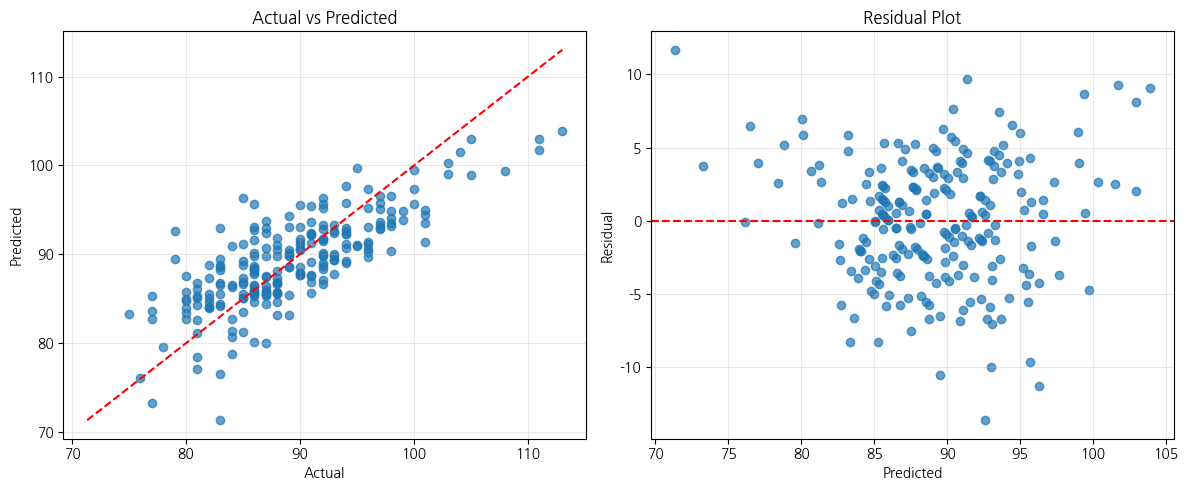

Cherry Time-lag B
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     54.71
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.85e-26
Time:                        04:14:36   Log-Likelihood:                -884.77
No. Observations:                 224   AIC:                             1778.
Df Residuals:                     220   BIC:                             1791.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const           

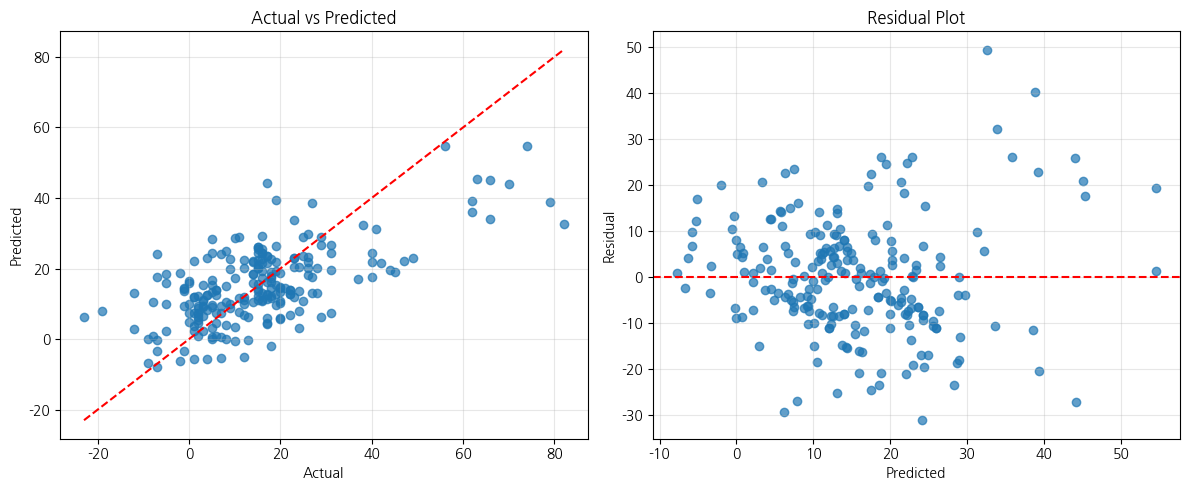

Bee start doy A
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     84.15
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.68e-36
Time:                        04:14:36   Log-Likelihood:                -903.88
No. Observations:                 224   AIC:                             1816.
Df Residuals:                     220   BIC:                             1829.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const             

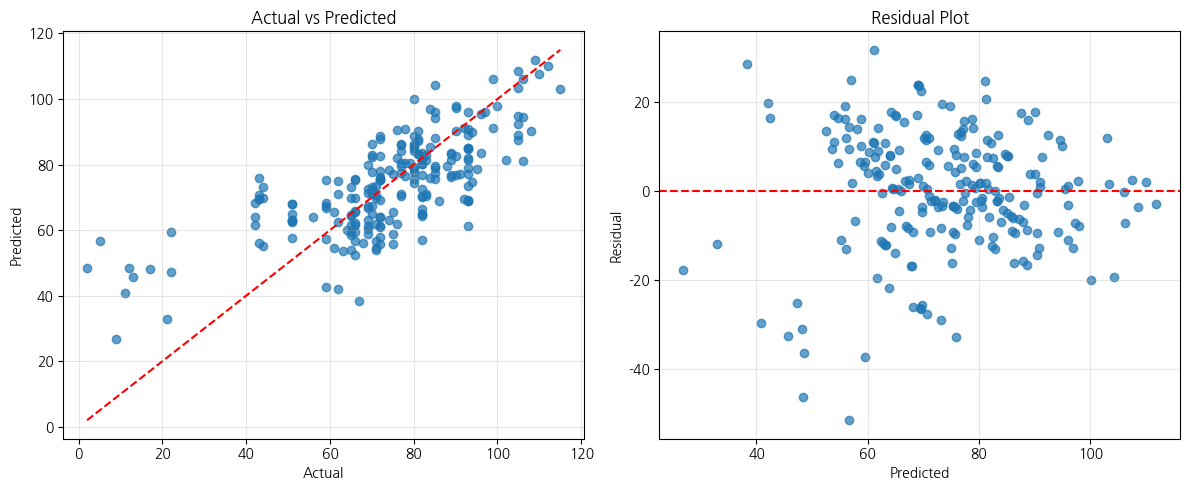

Bee start doy B
                            OLS Regression Results                            
Dep. Variable:          bee_start_doy   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     114.8
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           8.94e-45
Time:                        04:14:37   Log-Likelihood:                -883.94
No. Observations:                 224   AIC:                             1776.
Df Residuals:                     220   BIC:                             1790.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const             

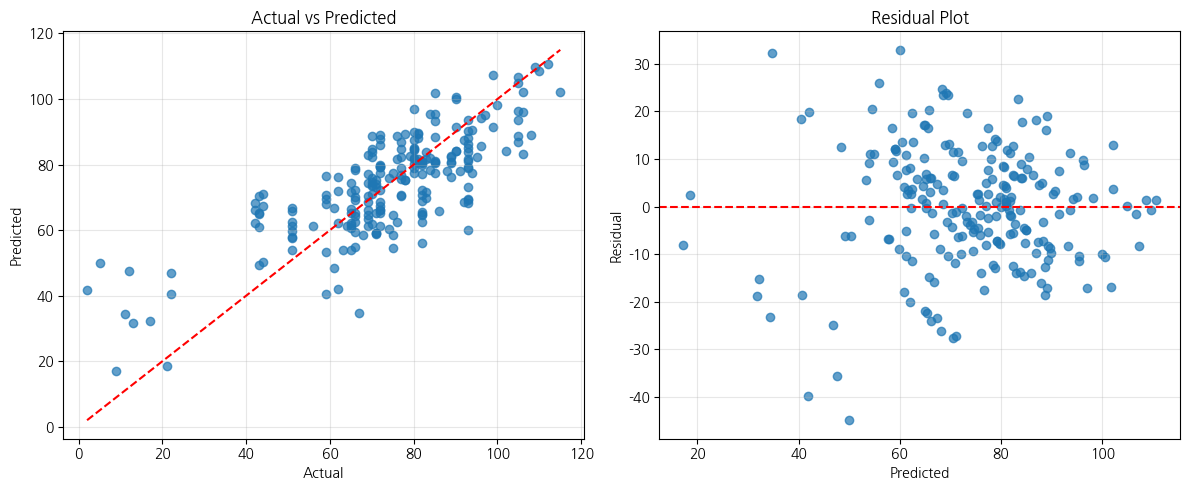

In [ ]:
# 최소 상대습도
robinia_min_temp1 = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_humidity_min", "bee_start_doy"],
    "robinia_bloom_doy",
    "Robinia bloom doy A"
)

robinia_min_temp2 = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_humidity_min"],
    "robinia_time_lag",
    "Robinia Time-lag A"
)

robinia_min_gdd1 = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_humidity_min", "bee_start_doy"],
    "robinia_bloom_doy",
    "Robinia bloom doy B"
)

robinia_min_gdd2 = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_humidity_min"],
    "robinia_time_lag",
    "Robinia Time-lag B"
)

cherry_min_temp1 = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_humidity_min", "bee_start_doy"],
    "cherry_bloom_doy",
    "Cherry bloom doy A"
)

cherry_min_temp2 = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_humidity_min"],
    "cherry_time_lag",
    "Cherry Time-lag A"
)

cherry_min_gdd1 = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_humidity_min", "bee_start_doy"],
    "cherry_bloom_doy",
    "Cherry bloom doy B"
)

cherry_min_gdd2 = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_humidity_min"],
    "cherry_time_lag",
    "Cherry Time-lag B"
)

bee_min_temp = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_humidity_min"],
    "bee_start_doy",
    "Bee start doy A"
)

bee_min_gdd = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_humidity_min"],
    "bee_start_doy",
    "Bee start doy B"
)

### 6개 다

Robinia Time-lag A
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     18.08
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           5.46e-17
Time:                        03:09:56   Log-Likelihood:                -897.52
No. Observations:                 224   AIC:                             1809.
Df Residuals:                     217   BIC:                             1833.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
con

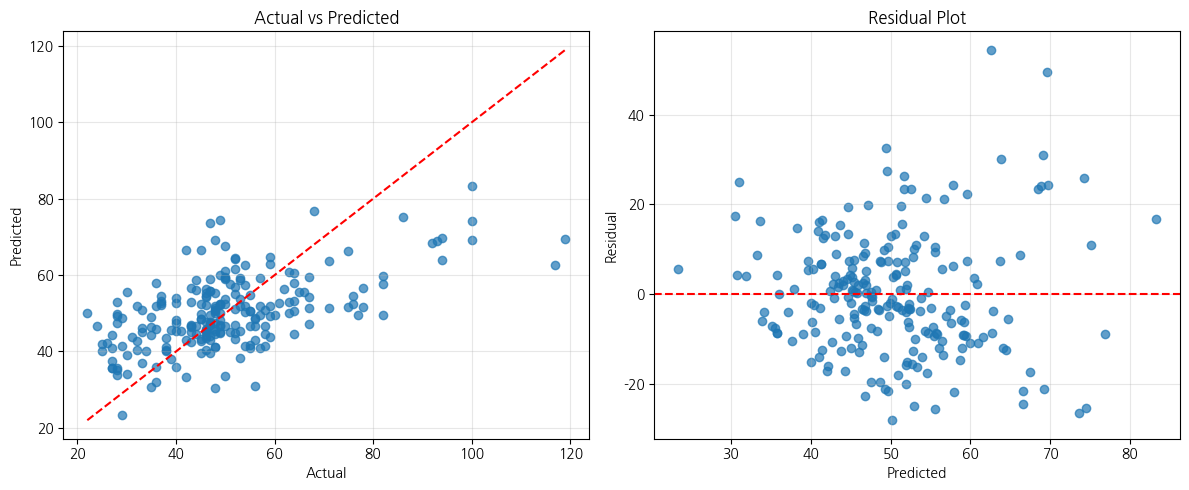

Robinia Time-lag B
                            OLS Regression Results                            
Dep. Variable:       robinia_time_lag   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     23.25
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.88e-21
Time:                        03:09:56   Log-Likelihood:                -887.34
No. Observations:                 224   AIC:                             1789.
Df Residuals:                     217   BIC:                             1813.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
con

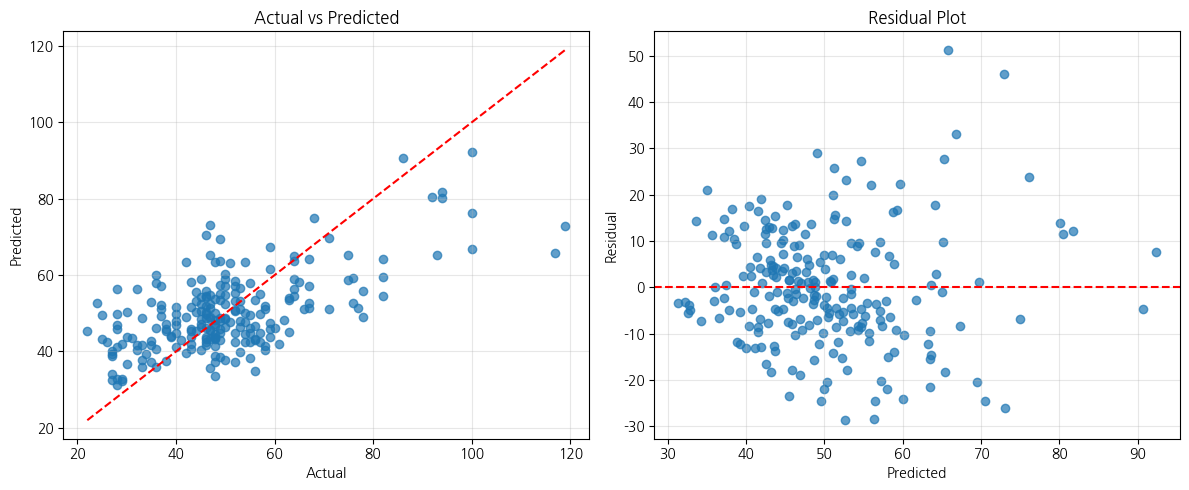

In [ ]:
# 아까시
# 봄평균기온
m_robinia_temp = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_dew_point_avg",
     "spring_humidity_min", "spring_humidity_avg", "spring_vapor_pressure_avg"],
    "robinia_time_lag",
    "Robinia Time-lag A"
)

# 적산온도
m_robinia_gdd = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_dew_point_avg",
     "spring_humidity_min", "spring_humidity_avg", "spring_vapor_pressure_avg"],
    "robinia_time_lag",
    "Robinia Time-lag B"
)

Cherry Time-lag A
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     23.01
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           5.92e-21
Time:                        03:09:57   Log-Likelihood:                -892.05
No. Observations:                 224   AIC:                             1798.
Df Residuals:                     217   BIC:                             1822.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
cons

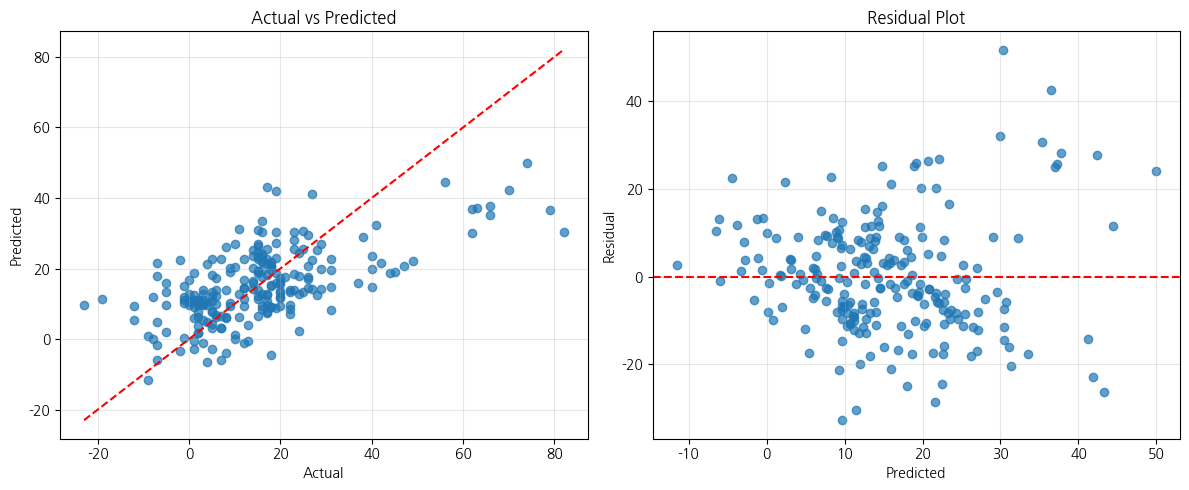

Cherry Time-lag B
                            OLS Regression Results                            
Dep. Variable:        cherry_time_lag   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     28.46
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           5.33e-25
Time:                        03:09:57   Log-Likelihood:                -882.18
No. Observations:                 224   AIC:                             1778.
Df Residuals:                     217   BIC:                             1802.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
cons

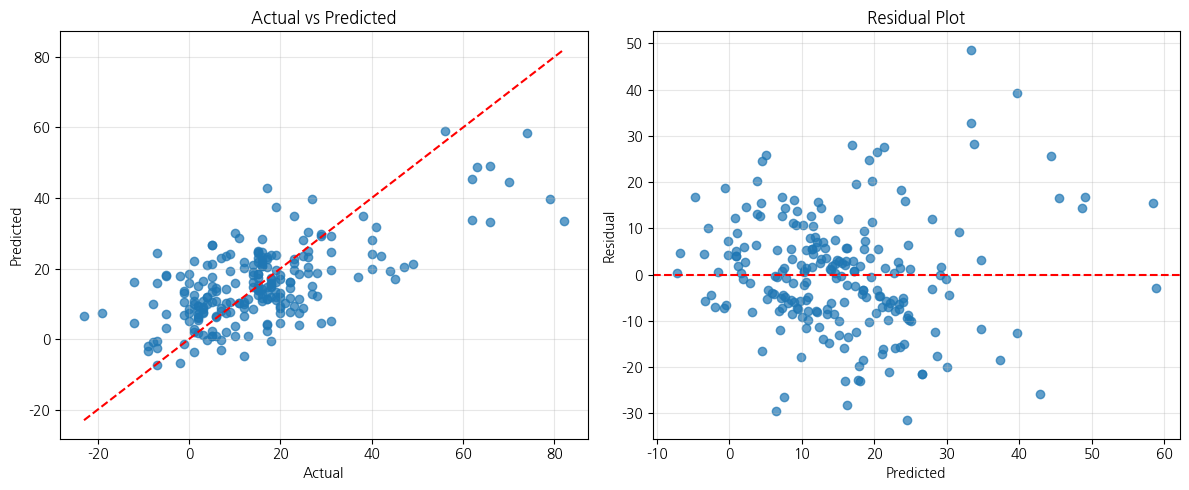

In [ ]:
# 벚나무
m_cherry_temp = multiple_regression(
    master_df,
    ["spring_temp_avg","spring_rainfall", "spring_dew_point_avg",
     "spring_humidity_min", "spring_humidity_avg", "spring_vapor_pressure_avg"],
    "cherry_time_lag",
    "Cherry Time-lag A"
)

# 적산온도
m_cherry_gdd = multiple_regression(
    master_df,
    ["accumulated_temp","spring_rainfall", "spring_dew_point_avg",
     "spring_humidity_min", "spring_humidity_avg", "spring_vapor_pressure_avg"],
    "cherry_time_lag",
    "Cherry Time-lag B"
)

# 종합

## 단순회귀

In [ ]:
# 모델 결과 요약 함수
def make_summary(result, name):

    model = result["model"]

    return {

        "Model": name,

        "β (Slope)": round(result["coef"],3),

        "Intercept": round(result["intercept"],3),

        "p-value": round(model.pvalues.iloc[1], 5),

        "R²": round(result["r2"],3),

        "Adj_R²": round(model.rsquared_adj, 3),

        "MAE": round(result["mae"], 3),

        "RMSE": round(result["rmse"], 3)

    }

In [ ]:
# 모델 결과 요약표
summary=[]

# 단순회귀
summary.append(make_summary(bee_temp_model, "Temp → Bee"))
summary.append(make_summary(bee_gdd_model, "GDD → Bee"))

summary.append(make_summary(robinia_temp_model, "Temp → Robinia"))
summary.append(make_summary(robinia_gdd_model, "GDD → Robinia"))

summary.append(make_summary(cherry_temp_model, "Temp → Cherry"))
summary.append(make_summary(cherry_gdd_model, "GDD → Cherry"))

summary.append(make_summary(lag_robinia_temp_model, "Temp → Robinia Lag"))
summary.append(make_summary(lag_robinia_gdd_model, "GDD → Robinia Lag"))

summary.append(make_summary(lag_cherry_temp_model, "Temp → Cherry Lag"))
summary.append(make_summary(lag_cherry_gdd_model, "GDD → Cherry Lag"))

summary_df = pd.DataFrame(summary)

display(summary_df)

,Model,β (Slope),Intercept,p-value,R²,Adj_R²,MAE,RMSE
0,Temp → Bee,-10.038,207.756,0.0,0.446,0.443,11.203,14.930
1,GDD → Bee,-0.106,159.959,0.0,0.567,0.565,10.241,13.198
2,Temp → Robinia,-5.696,200.063,0.0,0.767,0.766,3.296,4.187
3,GDD → Robinia,-0.051,165.665,0.0,0.706,0.705,3.565,4.701
4,Temp → Cherry,-3.703,138.637,0.0,0.560,0.558,3.573,4.422
5,GDD → Cherry,-0.033,116.169,0.0,0.542,0.540,3.649,4.509
6,Temp → Robinia Lag,4.342,-7.693,0.0,0.126,0.122,11.509,15.226
7,GDD → Robinia Lag,0.055,5.706,0.0,0.230,0.226,11.080,14.297
8,Temp → Cherry Lag,6.651,-73.038,0.0,0.269,0.266,10.962,14.754
9,GDD → Cherry Lag,0.073,-44.184,0.0,0.399,0.397,10.302,13.377


In [ ]:
summary_df['Variable Type'] = summary_df['Model'].apply(lambda x: 'Temperature' if 'Temp' in x else ('GDD' if 'GDD' in x else 'Other'))
display(summary_df.head())

,Model,β (Slope),Intercept,p-value,R²,Adj_R²,MAE,RMSE,Variable Type
0,Temp → Bee,-10.038,207.756,0.0,0.446,0.443,11.203,14.930,Temperature
1,GDD → Bee,-0.106,159.959,0.0,0.567,0.565,10.241,13.198,GDD
2,Temp → Robinia,-5.696,200.063,0.0,0.767,0.766,3.296,4.187,Temperature
3,GDD → Robinia,-0.051,165.665,0.0,0.706,0.705,3.565,4.701,GDD
4,Temp → Cherry,-3.703,138.637,0.0,0.560,0.558,3.573,4.422,Temperature


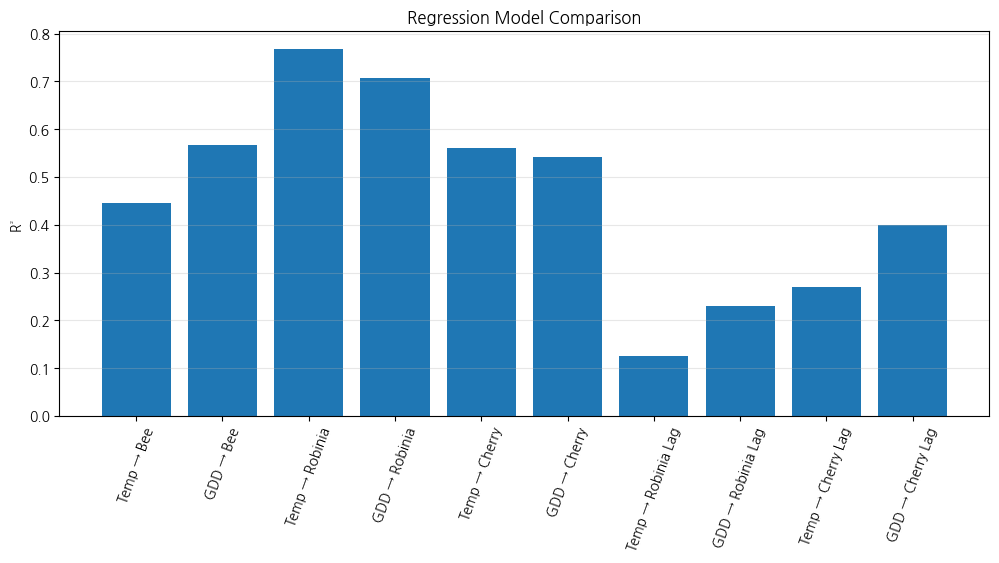

In [ ]:
# R² 비교 그래프
plt.figure(figsize=(12,5))

plt.bar(summary_df["Model"],summary_df["R²"])

plt.xticks(rotation=70)

plt.ylabel("R²")

plt.title("Regression Model Comparison")

plt.grid(axis="y",alpha=0.3)

plt.show()

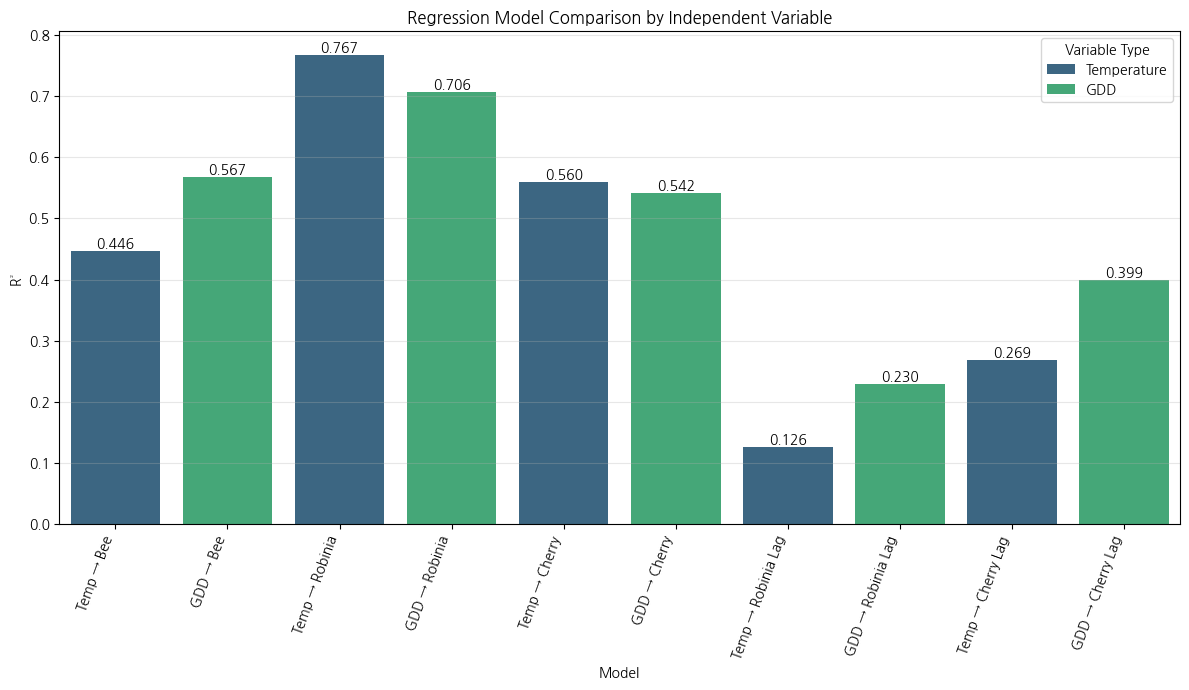

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,7))
ax = sns.barplot(x="Model", y="R²", hue="Variable Type", data=summary_df, palette="viridis")

# Add R^2 values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.xticks(rotation=70, ha='right')
plt.ylabel("R²")
plt.title("Regression Model Comparison by Independent Variable")
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

## 다중회귀

In [ ]:
def make_multiple_summary(result_dict, name):

    # result_dict에서 필요한 값들을 직접 추출합니다.
    params = result_dict["coef"]
    pvalues = result_dict["pvalues"]
    mae = result_dict["mae"]
    rmse = result_dict["rmse"]
    r2 = result_dict["r2"]
    adj_r2 = result_dict["adj_r2"]

    # Temp 또는 GDD 중 실제 모델에 들어간 변수 확인
    beta_temp_gdd = np.nan
    p_temp_gdd = np.nan
    if "spring_temp_avg" in params.index:
        beta_temp_gdd = params["spring_temp_avg"]
        p_temp_gdd = pvalues["spring_temp_avg"]
    elif "accumulated_temp" in params.index:
        beta_temp_gdd = params["accumulated_temp"]
        p_temp_gdd = pvalues["accumulated_temp"]

    return {
        "Model": name,

        "β: Temp/GDD": round(beta_temp_gdd, 3),
        "β: Rain": round(params.get("spring_rainfall", np.nan), 3),
        "β: RH_min": round(params.get("spring_humidity_min", np.nan), 3),
        "β: Bee": round(params.get("bee_start_doy", np.nan), 3),

        "p: Temp/GDD": round(p_temp_gdd, 5),
        "p: Rain": round(pvalues.get("spring_rainfall", np.nan), 5),
        "p: RH_min": round(pvalues.get("spring_humidity_min", np.nan), 5),
        "p: Bee": round(pvalues.get("bee_start_doy", np.nan), 5),

        "R²": round(r2, 3),
        "Adj_R²": round(adj_r2, 3),
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3)
    }

In [ ]:
summary = []

# --------------------------------------------------
# Robinia
# --------------------------------------------------

summary.append(
    make_multiple_summary(
        robinia_min_temp1,
        "Temp + Rain + RH_min + Bee → Robinia"
    )
)

summary.append(
    make_multiple_summary(
        robinia_min_temp2,
        "Temp + Rain + RH_min → Robinia Lag"
    )
)

summary.append(
    make_multiple_summary(
        robinia_min_gdd1,
        "GDD + Rain + RH_min + Bee → Robinia"
    )
)

summary.append(
    make_multiple_summary(
        robinia_min_gdd2,
        "GDD + Rain + RH_min → Robinia Lag"
    )
)


# --------------------------------------------------
# Cherry
# --------------------------------------------------

summary.append(
    make_multiple_summary(
        cherry_min_temp1,
        "Temp + Rain + RH_min + Bee → Cherry"
    )
)

summary.append(
    make_multiple_summary(
        cherry_min_temp2,
        "Temp + Rain + RH_min → Cherry Lag"
    )
)

summary.append(
    make_multiple_summary(
        cherry_min_gdd1,
        "GDD + Rain + RH_min + Bee → Cherry"
    )
)

summary.append(
    make_multiple_summary(
        cherry_min_gdd2,
        "GDD + Rain + RH_min → Cherry Lag"
    )
)


# --------------------------------------------------
# Bee
# --------------------------------------------------

summary.append(
    make_multiple_summary(
        bee_min_temp,
        "Temp + Rain + RH_min → Bee"
    )
)

summary.append(
    make_multiple_summary(
        bee_min_gdd,
        "GDD + Rain + RH_min → Bee"
    )
)


# --------------------------------------------------
# 통합표
# --------------------------------------------------

summary_df = pd.DataFrame(summary)

display(summary_df)

,Model,β: Temp/GDD,β: Rain,β: RH_min,β: Bee,p: Temp/GDD,p: Rain,p: RH_min,p: Bee,R²,Adj_R²,MAE,RMSE
0,Temp + Rain + RH_min + Bee → Robinia,-5.088,-0.004,0.123,0.036,0.0,0.15743,0.00300,0.07802,0.777,0.773,3.207,4.093
1,Temp + Rain + RH_min → Robinia Lag,4.815,0.014,0.700,NaN,0.0,0.14407,0.00000,NaN,0.281,0.271,10.631,13.815
2,GDD + Rain + RH_min + Bee → Robinia,-0.048,-0.005,0.225,0.010,0.0,0.11117,0.00000,0.68179,0.742,0.737,3.434,4.408
3,GDD + Rain + RH_min → Robinia Lag,0.055,0.008,0.643,NaN,0.0,0.39306,0.00000,NaN,0.348,0.339,10.230,13.157
4,Temp + Rain + RH_min + Bee → Cherry,-2.822,-0.007,0.038,0.075,0.0,0.02393,0.36089,0.00035,0.611,0.604,3.359,4.177
5,Temp + Rain + RH_min → Cherry Lag,6.679,0.011,0.592,NaN,0.0,0.24744,0.00001,NaN,0.355,0.347,10.164,13.331
6,GDD + Rain + RH_min + Bee → Cherry,-0.028,-0.007,0.090,0.055,0.0,0.01992,0.02552,0.01747,0.603,0.596,3.400,4.218
7,GDD + Rain + RH_min → Cherry Lag,0.070,0.005,0.489,NaN,0.0,0.54759,0.00003,NaN,0.427,0.419,9.679,12.565
8,Temp + Rain + RH_min → Bee,-10.271,-0.019,-0.599,NaN,0.0,0.04896,0.00001,NaN,0.534,0.528,10.527,13.684
9,GDD + Rain + RH_min → Bee,-0.104,-0.013,-0.422,NaN,0.0,0.14001,0.00031,NaN,0.610,0.605,9.752,12.519
